# DopplerNet-SA+XPINN B1 — DopplerSim Speed Estimation (JAX)

Production notebook for **DopplerNet-SA+XPINN hybrid** speed regression (DopplerAttn2D + XPINN physics).

## GCP VM (`dopplernet-sa-xpinn-train`)

```bash
# One-time setup
git clone https://github.com/seetharamkkv/DopplerLab.git
cd DopplerLab
python3 -m venv .venv && source .venv/bin/activate
pip install -U pip "jax[cuda12]" flax optax tqdm scikit-learn pandas matplotlib seaborn msgpack jupyter papermill

# Mount attached data disk (read-only)
sudo mkdir -p /mnt/doppler-data
sudo mount -o ro /dev/nvme0n2p1 /mnt/doppler-data
ls /mnt/doppler-data/home/rohithas/DopplerSim/static/batch_outputs/
# -> B1_to_B6_1Mil  test

# Optional symlink (notebook also auto-detects /mnt/doppler-data/...)
ln -sf /mnt/doppler-data/home/rohithas/DopplerSim/static/batch_outputs data/batch_outputs

# Headless training (tmux recommended)
papermill DopplerNet_SA_XPINN.ipynb outputs/run.ipynb --log-output
```

**Dataset:** `B1_to_B6_1Mil` under `batch_outputs/` (same layout as `model_test_1000`: `dataset.csv` + `audio_clips/sample_*/Common/cqt.npy`).

Experiments write to `experiments/test_dopplernet_sa_xpinn/` (gitignored).

| Section | Contents |
|---------|----------|
| **1. Setup** | Config, mounted-disk batch discovery, speed-stratified splits |
| **2. Training** | DopplerAttn2D + XPINN, checkpoints + per-epoch metrics |
| **3. Evaluation** | Test metrics, predictions, plots |

**Split policy:** one scene per split only; ~70/15/15 within each speed bin.


In [1]:
# RUN CONTROL — edit before executing
TEST = False

# Fresh training weights; reuse cached 1M manifest + splits (no ~30 min rebuild)
RESUME_TRAINING = False
ONLY_EVALUATION = False
REFRESH_SETUP_CACHE = False   # keep setup_cache/ manifest + split_indices.json
START_FRESH = True            # wipe checkpoints + results only (NOT setup_cache)

EPOCHS = 80
TEST_N_CLIPS = 3
DATASET_BATCH_NAME = "B1_to_B6_1Mil"

# Throughput (same train/val/test clips — only faster I/O + larger GPU batches)
BATCH_SIZE = 32
NUM_WORKERS = 8
PREFETCH_BATCHES = 4

if TEST:
    EPOCHS = 1
    REFRESH_SETUP_CACHE = True
    RESUME_TRAINING = False
    START_FRESH = True
    TEST_N_CLIPS = max(3, int(TEST_N_CLIPS))
    print(f"TEST mode ON — {TEST_N_CLIPS} clips, 1 epoch, batch_size=1")
else:
    print(f"FRESH TRAINING — {DATASET_BATCH_NAME}, epochs={EPOCHS}, BATCH_SIZE={BATCH_SIZE}")
    print("Keeps setup_cache splits. Wipes old checkpoints/results (START_FRESH=True).")

IN_COLAB = "google.colab" in __import__("sys").modules
if IN_COLAB:
    print("Colab — use GCP VM for B1_to_B6_1Mil.")


FRESH TRAINING — B1_to_B6_1Mil, epochs=80, BATCH_SIZE=32
Keeps setup_cache splits. Wipes old checkpoints/results (START_FRESH=True).


# 1. Setup

Environment, imports, **relative repo paths**, attached-disk batch discovery, speed-stratified splits (leakage-checked), experiment dirs under `experiments/test_dopplernet_sa_xpinn/`.


In [2]:
# Dependency installation
import importlib.util
import os
import re
import shutil
import subprocess
import sys

# System CUDA on LD_LIBRARY_PATH breaks JAX's pip-bundled cuDNN (CUDNN_STATUS_SUBLIBRARY_LOADING_FAILED).
if os.environ.get("LD_LIBRARY_PATH", "").lower().find("cuda") >= 0:
    print("WARN: clearing LD_LIBRARY_PATH (system CUDA was overriding JAX cuDNN)")
    os.environ.pop("LD_LIBRARY_PATH", None)


def _package_base(pkg: str) -> str:
    """Strip extras/version pins: 'nvidia-cudnn-cu12>=9.8' -> 'nvidia-cudnn-cu12'."""
    return re.split(r"[<>=!~\\[]", pkg, maxsplit=1)[0].strip()


def _pip(*packages):
    for pkg in packages:
        base = _package_base(pkg)
        # NVIDIA wheels are native libs — not importable; always pip-check via jax instead.
        if base.startswith("nvidia-"):
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
            continue
        spec_name = "sklearn" if base == "scikit-learn" else base.replace("-", "_")
        if importlib.util.find_spec(spec_name) is None:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


def _has_nvidia_gpu() -> bool:
    return shutil.which("nvidia-smi") is not None and subprocess.call(
        ["nvidia-smi"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    ) == 0


if _has_nvidia_gpu():
    _pip("jax[cuda12]", "nvidia-cudnn-cu12>=9.8.0,<10.0.0")
else:
    _pip("jax")
_pip("flax", "optax", "tqdm", "scikit-learn", "pandas", "matplotlib", "seaborn", "msgpack")


In [3]:
# Imports
from __future__ import annotations

import gc
import hashlib
import json
import math
import os
import pickle
import random
import shutil
import sys
import time
import warnings
from collections import defaultdict
from dataclasses import asdict, dataclass
from functools import partial
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import msgpack
import numpy as np
import optax
import pandas as pd
import re
import seaborn as sns
from flax import serialization, traverse_util
from flax import struct
from flax.training import train_state
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)


In [4]:
# Configuration (single source of truth)
# EPOCHS from RUN CONTROL; DATASET_BATCH_NAME optional
if "EPOCHS" not in globals():
    EPOCHS = 80
if "DATASET_BATCH_NAME" not in globals():
    DATASET_BATCH_NAME = "B1_to_B6_1Mil"
if "TEST" not in globals():
    TEST = False
if "TEST_N_CLIPS" not in globals():
    TEST_N_CLIPS = 3
if "BATCH_SIZE" not in globals():
    BATCH_SIZE = 0
if "NUM_WORKERS" not in globals():
    NUM_WORKERS = 8
if "PREFETCH_BATCHES" not in globals():
    PREFETCH_BATCHES = 4


def find_repo_root() -> Path:
    """Repo root = folder containing this notebook (works after git clone)."""
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "DopplerNet_SA_XPINN.ipynb").exists():
            return candidate
        if (candidate / ".git").exists():
            return candidate
    return cwd


REPO_ROOT = find_repo_root()


@dataclass
class Config:
    seed: int = 42
    num_workers: int = 1 if TEST else max(1, int(NUM_WORKERS))
    prefetch_batches: int = 0 if TEST else max(0, int(PREFETCH_BATCHES))
    feature_cache_max: int = 4096
    lr_batch_ref: int = 16

    # --- Dataset (relative / attached disk; no Google Drive paths) ---
    test_mode: bool = TEST
    test_n_clips: int = TEST_N_CLIPS
    test_csv_scan_rows: int = 512  # TEST only: read head of dataset.csv (avoid 1M-row scan)
    dataset_batch_name: str = DATASET_BATCH_NAME  # subfolder under batch_outputs/
    batch_outputs_relpath: str = "data/batch_outputs"  # symlink -> attached disk
    dataset_csv: str = "dataset.csv"
    audio_clips_subdir: str = "audio_clips"
    feature_subdir: str = "Common"
    b1_label_subdir: str = "B1_Speed"
    use_synthetic_if_missing: bool = False

    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15
    speed_bin_edges: Tuple[float, ...] = (10, 15, 20, 25, 30, 35, 40, 45, 50)
    split_indices_file: str = "split_indices.json"
    manifest_source: str = "auto"
    verify_features_on_manifest: bool = False
    manifest_spot_check_n: int = 8
    manifest_json_max_clips: int = 50_000

    # --- Experiments (relative to REPO_ROOT; gitignored) ---
    experiment_name: str = "test_dopplernet_sa_xpinn_smoke" if TEST else "test_dopplernet_sa_xpinn"
    experiment_relpath: str = "experiments"
    checkpoint_epoch: str = "checkpoint_latest.msgpack"
    resume_state_file: str = "resume_state.json"
    mae_history_file: str = "mae_history.npy"
    r2_history_file: str = "r2_history.npy"
    pred_std_history_file: str = "prediction_std_history.npy"
    metrics_file: str = "metrics_latest.json"
    history_file: str = "training_history.json"
    predictions_file: str = "predictions_latest.npz"
    eval_report_file: str = "eval_report_latest.json"
    summary_report_file: str = "summary_report_latest.txt"
    results_dir: str = "results"
    inference_dir: str = "inference_outputs"

    # phsweep_cqt = PhySweep default: log-CQT + optional per-bin norm
    # multi_hop_cqt = multi-channel CQT (stacked scales / channels)
    # frequency_only = ablation baseline
    input_mode: str = "doppler_attn_2d"
    cqt_per_bin_norm: bool = True  # selective trick from benchmarks; not a copied architecture
    cqt_norm_eps: float = 1e-6
    n_cqt_bins: int = 84
    n_time_frames: int = 432  # SelfAttention DopplerNet 2D
    n_hops: int = 3
    clip_duration_sec: float = 10.0
    speed_min: float = 0.0
    speed_max: float = 50.0
    dist_max_m: float = 100.0
    speed_target_normalized: bool = True

    val_batch_ids: Tuple[str, ...] = ()  # optional batch holdout when sidecars exist
    test_batch_ids: Tuple[str, ...] = ()

    attn_d_model: int = 128
    attn_n_layers: int = 2
    attn_n_heads: int = 4
    attn_dim_ff: int = 256
    attn_dropout: float = 0.1
    attn_max_len: int = 200
    d_model: int = 256
    n_temporal_layers: int = 4
    n_heads: int = 8
    conv_stages: int = 3
    time_stride: int = 4
    dropout: float = 0.1
    predict_nuisances: bool = True  # joint (v, d, t_CPA) for physics renderer
    xpinn_enabled: bool = True  # XPINN regional router + regional physics losses
    n_xpin_regions: int = 3  # approach / CPA / recede
    physics_use_gt_cpa_masks: bool = True  # GT CPA time for region masks (train only)
    multitask_aux: bool = True  # light path/distance aux (lambda_path/dist in Config)
    path_class_names: Tuple[str, ...] = ("straight", "parabola", "bezier")
    n_path_classes: int = 3

    c_sound: float = 343.0
    wing_tau_sec: float = 1.5

    lambda_sup: float = 1.0
    lambda_path: float = 0.2
    lambda_dist: float = 0.15
    lambda_router: float = 0.1  # router ↔ XPINN region alignment
    lambda_nll: float = 0.2
    lambda_dopp: float = 0.05
    lambda_spec: float = 0.1
    lambda_smooth: float = 0.01
    lambda_con: float = 0.5
    lambda_dom: float = 0.1
    lambda_mcqt: float = 0.3
    huber_delta: float = 0.5
    physics_cap_ratio: float = 0.3
    renderer_stopgrad_epochs: int = 10

    phase_a_end: int = 20
    phase_b_end: int = 60

    batch_size: int = 1 if TEST else (int(BATCH_SIZE) if int(BATCH_SIZE) > 0 else 64)
    augment_gain: bool = True  # mild level jitter (optional regularizer)
    gain_jitter_range: Tuple[float, float] = (0.85, 1.15)
    epochs: int = EPOCHS
    lr: float = 3e-4
    lr_min_ratio: float = 0.05  # cosine floor: 5% of peak lr
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    val_every_epochs: int = 2
    progress_update_every: int = 10
    progress_log_every: int = 50  # line logs for papermill (every N batches)
    mcqt_mask_ratio: float = 0.15

    n_mc_dropout: int = 5
    calibration_bins: int = 15
    snr_eval_db: Tuple[float, ...] = (20.0, 10.0, 5.0, 0.0)
    fgsm_eps: Tuple[float, ...] = (0.01, 0.03, 0.05)


CFG = Config()


def effective_training_lr(cfg: Config = CFG) -> float:
    return cfg.lr * (cfg.batch_size / max(1, cfg.lr_batch_ref))

EXP_ROOT = (REPO_ROOT / CFG.experiment_relpath / CFG.experiment_name).resolve()
CKPT_DIR = EXP_ROOT / "checkpoints"
SETUP_CACHE_DIR = EXP_ROOT / "setup_cache"
RESULTS_DIR = EXP_ROOT / CFG.results_dir
RESULTS_DATASET_DIR = RESULTS_DIR / "dataset"
RESULTS_TRAINING_DIR = RESULTS_DIR / "training"
RESULTS_EVAL_DIR = RESULTS_DIR / "evaluation"
RESULTS_METRICS_DIR = RESULTS_DIR / "metrics"
RUN_LOG_FILE = RESULTS_DIR / "run.log"
LEGACY_LOG_DIR = EXP_ROOT / "logs"
LEGACY_INF_DIR = EXP_ROOT / CFG.inference_dir
# Aliases used by training / checkpoint helpers
LOG_DIR = RESULTS_METRICS_DIR
INF_DIR = RESULTS_EVAL_DIR


def ensure_experiment_dirs() -> None:
    for p in (
        EXP_ROOT,
        CKPT_DIR,
        SETUP_CACHE_DIR,
        RESULTS_DIR,
        RESULTS_DATASET_DIR,
        RESULTS_TRAINING_DIR,
        RESULTS_EVAL_DIR,
        RESULTS_METRICS_DIR,
    ):
        p.mkdir(parents=True, exist_ok=True)


def resolve_artifact_path(filename: str, prefer_dir: Path, legacy_dir: Optional[Path] = None) -> Path:
    """Read path: prefer new layout, fall back to legacy logs/ if present."""
    preferred = prefer_dir / filename
    if preferred.exists():
        return preferred
    if legacy_dir is not None:
        legacy = legacy_dir / filename
        if legacy.exists():
            return legacy
    return preferred


def run_log(message: str, level: str = "INFO") -> None:
    """Lightweight append-only experiment log (results/run.log)."""
    ts = time.strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{ts}] [{level}] {message}"
    print(line)
    try:
        RUN_LOG_FILE.parent.mkdir(parents=True, exist_ok=True)
        with open(RUN_LOG_FILE, "a", encoding="utf-8") as f:
            f.write(line + "\n")
    except Exception:
        pass


# Attached persistent disk candidates (GCP: mount Rohitha's disk, do not copy 1M clips)
ATTACHED_BATCH_OUTPUTS_CANDIDATES = [
    Path("/mnt/doppler-data/home/rohithas/DopplerSim/static/batch_outputs"),
    Path("/home/rohithas/DopplerSim/static/batch_outputs"),
    Path("/mnt/rohitha-data/home/rohithas/DopplerSim/static/batch_outputs"),
]


def resolve_batch_outputs_root() -> Path:
    """Root containing batch subfolders (each with dataset.csv + audio_clips/)."""
    env = os.environ.get("DOPPLER_BATCH_OUTPUTS", "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if p.is_dir():
            return p
        raise FileNotFoundError(f"DOPPLER_BATCH_OUTPUTS not found: {p}")
    for c in ATTACHED_BATCH_OUTPUTS_CANDIDATES:
        if c.is_dir():
            run_log(f"Using attached batch_outputs: {c}")
            return c.resolve()
    rel = (REPO_ROOT / CFG.batch_outputs_relpath).resolve()
    if rel.is_dir():
        return rel
    raise FileNotFoundError(
        "No batch_outputs found. Mount data disk and run:\n"
        "  sudo mount -o ro /dev/nvme0n2p1 /mnt/doppler-data\n"
        "Or: export DOPPLER_BATCH_OUTPUTS=/mnt/doppler-data/home/rohithas/DopplerSim/static/batch_outputs\n"
        f"Or symlink: ln -sf /mnt/doppler-data/home/rohithas/DopplerSim/static/batch_outputs {rel}"
    )


def _valid_batch_root(p: Path) -> bool:
    clips = p / CFG.audio_clips_subdir
    return p.is_dir() and (p / CFG.dataset_csv).is_file() and clips.is_dir() and any(clips.glob("sample_*"))


def resolve_batch_root() -> Path:
    outputs_root = resolve_batch_outputs_root()
    batch_name = os.environ.get("DOPPLER_BATCH_NAME", CFG.dataset_batch_name or "").strip()
    if batch_name:
        candidate = outputs_root / batch_name
        if _valid_batch_root(candidate):
            return candidate
        raise FileNotFoundError(f"Batch folder not found or invalid: {candidate}")
    batches = [c for c in outputs_root.iterdir() if c.is_dir() and _valid_batch_root(c)]
    if not batches:
        raise FileNotFoundError(f"No valid DopplerSim batch under {outputs_root}")
    if len(batches) == 1:
        return batches[0]
    best = max(batches, key=lambda p: len(list((p / CFG.audio_clips_subdir).glob("sample_*"))))
    print(f"Auto-selected batch '{best.name}' ({len(list((best / CFG.audio_clips_subdir).glob('sample_*')))} clips)")
    return best


def save_figure(fig, path: Path, *, show: bool = True) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=120, bbox_inches="tight")
    run_log(f"Saved figure -> {path}")
    if show:
        plt.show()
    return path



ensure_experiment_dirs()
run_log(f"Experiment initialized: {EXP_ROOT}")
run_log(
    f"Results layout: dataset={RESULTS_DATASET_DIR.name}/ training={RESULTS_TRAINING_DIR.name}/ "
    f"evaluation={RESULTS_EVAL_DIR.name}/ metrics={RESULTS_METRICS_DIR.name}/"
)

print(f"JAX devices: {jax.devices()}")
print(f"Repo root:       {REPO_ROOT}")
print(f"Experiment root: {EXP_ROOT.relative_to(REPO_ROOT)}")
print(f"Results root:    {RESULTS_DIR}")
print(f"Setup cache:     {SETUP_CACHE_DIR}")
print(
    f"Throughput: batch={CFG.batch_size} workers={CFG.num_workers} "
    f"prefetch={CFG.prefetch_batches} cache={CFG.feature_cache_max} "
    f"peak_lr={effective_training_lr():.2e}"
)


[2026-05-31 20:04:31] [INFO] Experiment initialized: /home/skilliva/DopplerLab/experiments/test_dopplernet_sa_xpinn
[2026-05-31 20:04:31] [INFO] Results layout: dataset=dataset/ training=training/ evaluation=evaluation/ metrics=metrics/


JAX devices: [CudaDevice(id=0)]
Repo root:       /home/skilliva/DopplerLab
Experiment root: experiments/test_dopplernet_sa_xpinn
Results root:    /home/skilliva/DopplerLab/experiments/test_dopplernet_sa_xpinn/results
Setup cache:     /home/skilliva/DopplerLab/experiments/test_dopplernet_sa_xpinn/setup_cache
Throughput: batch=32 workers=8 prefetch=4 cache=4096 peak_lr=6.00e-04


In [5]:
# Reproducibility
def set_seed(seed: int = CFG.seed):
    random.seed(seed)
    np.random.seed(seed)
    return jax.random.PRNGKey(seed)

MASTER_KEY = set_seed(CFG.seed)


In [6]:
# Resolve DopplerSim batch on attached disk / data/batch_outputs/
def print_batch_summary(batch_root: Path) -> None:
    prog_path = batch_root / "progress.json"
    if prog_path.exists():
        prog = json.loads(prog_path.read_text(encoding="utf-8"))
        print(
            f"Batch progress: {prog.get('generated_so_far', '?')}/"
            f"{prog.get('total_target', '?')} ({prog.get('status', prog.get('phase', '?'))})"
        )
    meta_files = sorted(batch_root.glob("metadata_*.json"))
    if meta_files:
        meta = json.loads(meta_files[0].read_text(encoding="utf-8"))
        print(f"Batch ID: {meta.get('batch_id', batch_root.name)}")
    csv_path = batch_root / CFG.dataset_csv
    if csv_path.exists():
        n_rows = sum(1 for _ in open(csv_path, encoding="utf-8")) - 1
        print(f"  manifest: {csv_path.name} ({n_rows} rows)")


BATCH_OUTPUTS_ROOT = resolve_batch_outputs_root()
BATCH_ROOT = resolve_batch_root()
CLIPS_ROOT = BATCH_ROOT / CFG.audio_clips_subdir
DATA_ROOT = CLIPS_ROOT
n_samples = len(list(CLIPS_ROOT.glob("sample_*")))
print(f"batch_outputs root: {BATCH_OUTPUTS_ROOT}")
print(f"Batch root:         {BATCH_ROOT}")
print(f"Sample folders:     {n_samples}")
print_batch_summary(BATCH_ROOT)
run_log(f"Dataset batch={BATCH_ROOT.name} clips={n_samples}")


batch_outputs root: /mnt/doppler-data/home/rohithas/DopplerSim/static/batch_outputs
Batch root:         /mnt/doppler-data/home/rohithas/DopplerSim/static/batch_outputs/B1_to_B6_1Mil
Sample folders:     1000000
Batch progress: 1000000/1000000 (completed)
Batch ID: B1_to_B6_1Mil


  manifest: dataset.csv (1000000 rows)
[2026-05-31 20:04:40] [INFO] Dataset batch=B1_to_B6_1Mil clips=1000000


In [7]:
# Checkpoint hygiene (respect RESUME_TRAINING / START_FRESH / ONLY_EVALUATION)
def wipe_experiment_artifacts():
    if RESULTS_DIR.exists():
        shutil.rmtree(RESULTS_DIR)
    ensure_experiment_dirs()
    for legacy in (LEGACY_LOG_DIR, LEGACY_INF_DIR):
        if legacy.exists():
            shutil.rmtree(legacy)
    for ckpt_name in (CFG.checkpoint_epoch, "checkpoint_batch.msgpack", "checkpoint_best.msgpack"):
        p = CKPT_DIR / ckpt_name
        if p.exists():
            p.unlink()
    run_log("START_FRESH: wiped results/ and checkpoints", level="WARN")
    print("Removed previous experiment artifacts (overwrite policy).")


def discover_checkpoints() -> List[Path]:
    """Search experiment dirs under repo for checkpoints."""
    found = []
    exp_base = (REPO_ROOT / CFG.experiment_relpath).resolve()
    roots = [EXP_ROOT]
    if exp_base.is_dir():
        for child in exp_base.iterdir():
            if child.is_dir():
                roots.append(child)
    seen = set()
    for root in roots:
        key = str(root.resolve())
        if key in seen:
            continue
        seen.add(key)
        path = root / "checkpoints" / CFG.checkpoint_epoch
        if path.exists():
            found.append(path)
    return found


def print_checkpoint_status():
    ckpt_path = CKPT_DIR / CFG.checkpoint_epoch
    resume_path = resolve_artifact_path(CFG.resume_state_file, RESULTS_METRICS_DIR, LEGACY_LOG_DIR)
    print(f"Active experiment root: {EXP_ROOT}")
    print(f"  checkpoint: {ckpt_path} {'EXISTS' if ckpt_path.exists() else 'missing'}")
    print(f"  resume log: {resume_path} {'EXISTS' if resume_path.exists() else 'missing'}")
    if resume_path.exists():
        try:
            with open(resume_path, encoding="utf-8") as f:
                rs = json.load(f)
            print(
                f"  resume from: epoch {rs.get('epoch_display', rs.get('epoch', '?'))}, "
                f"batch {rs.get('resume_batch', 0) + 1}"
            )
        except Exception:
            pass
    elsewhere = []
    for p in discover_checkpoints():
        try:
            p.relative_to(CKPT_DIR)
        except ValueError:
            elsewhere.append(p)
    if elsewhere:
        print("Other checkpoint files found (update CFG.experiment_name under experiments/):")
        for p in elsewhere:
            print(f"  {p}")


print_checkpoint_status()
run_log("Checkpoint status printed")

if ONLY_EVALUATION:
    print("ONLY_EVALUATION=True: preserving existing checkpoints for evaluation.")
elif START_FRESH:
    print("START_FRESH=True: wiping checkpoints under experiments/<name>/.")
    wipe_experiment_artifacts()
elif RESUME_TRAINING:
    print("RESUME_TRAINING=True: will resume from checkpoint_latest if present, else start a new run.")
else:
    print("RESUME_TRAINING=False: starting new run without wiping old checkpoints.")


Active experiment root: /home/skilliva/DopplerLab/experiments/test_dopplernet_sa_xpinn
  checkpoint: /home/skilliva/DopplerLab/experiments/test_dopplernet_sa_xpinn/checkpoints/checkpoint_latest.msgpack missing
  resume log: /home/skilliva/DopplerLab/experiments/test_dopplernet_sa_xpinn/results/metrics/resume_state.json missing
Other checkpoint files found (update CFG.experiment_name under experiments/):
  /home/skilliva/DopplerLab/experiments/test_dopplernet_sa_xpinn_smoke/checkpoints/checkpoint_latest.msgpack
[2026-05-31 20:04:40] [INFO] Checkpoint status printed
START_FRESH=True: wiping checkpoints under experiments/<name>/.
[2026-05-31 20:04:40] [WARN] START_FRESH: wiped results/ and checkpoints
Removed previous experiment artifacts (overwrite policy).


Loaded manifest from setup cache: 1000000 clips (saved 2026-05-31 14:31)



=== Split balance report ===
| Check | Status |
|-------|--------|
| Scene leakage | NO — disjoint clip_id / sample_dir (one scene per folder) |
| Split method | Speed-stratified regression (~70/15/15 within each speed bin) |
| train size | 700002 clips (70.0%) |
| val   size | 149999 clips (15.0%) |
| test  size | 149999 clips (15.0%) |



Speed bin coverage (target: all splits represented when bin has >=3 clips):
Speed Bin  Train Count  Val Count  Test Count
    10-15       187605      40201       40201
    15-20        71144      15245       15245
    20-25        71310      15280       15280
    25-30        71067      15228       15228
    30-35        71127      15241       15241
    35-40        71125      15241       15241
    40-45        71150      15247       15247
    45-50        85474      18316       18316

Fraction of each speed bin in train / val / test:
Speed Bin  train  val  test
    10-15    0.7 0.15  0.15
    15-20    0.7 0.15  0.15
    20-25    0.7 0.15  0.15
    25-30    0.7 0.15  0.15
    30-35    0.7 0.15  0.15
    35-40    0.7 0.15  0.15
    40-45    0.7 0.15  0.15
    45-50    0.7 0.15  0.15

=== Speed split summary ===
  train: n=700002  min=-50.0  max= 50.0  mean= 20.03  median= 26.00  std=25.26
  val  : n=149999  min=-50.0  max= 50.0  mean= 20.01  median= 26.00  std=25.30


  test : n=149999  min=-50.0  max= 50.0  mean= 19.98  median= 26.00  std=25.34


[2026-05-31 20:04:51] [INFO] Saved figure -> /home/skilliva/DopplerLab/experiments/test_dopplernet_sa_xpinn/results/dataset/speed_histograms_per_split.png


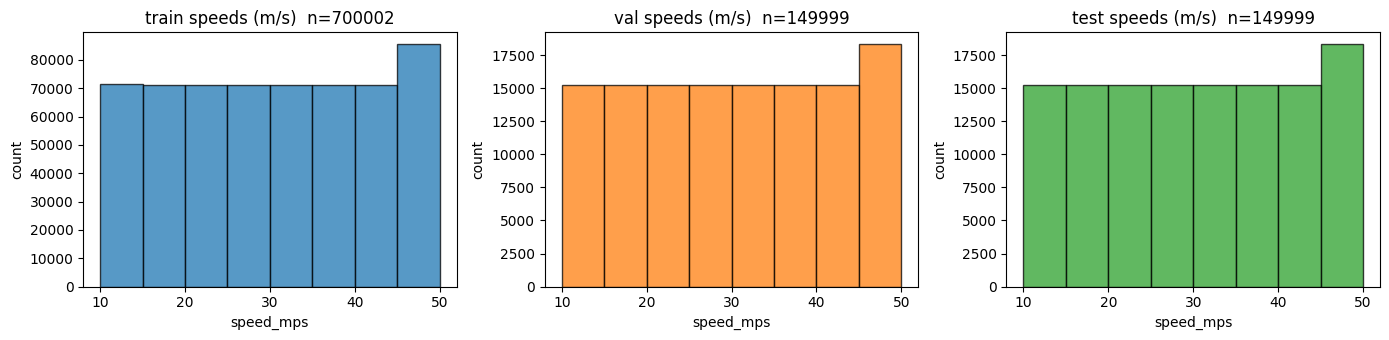

[2026-05-31 20:04:52] [INFO] Saved figure -> /home/skilliva/DopplerLab/experiments/test_dopplernet_sa_xpinn/results/dataset/speed_histogram_overlay.png


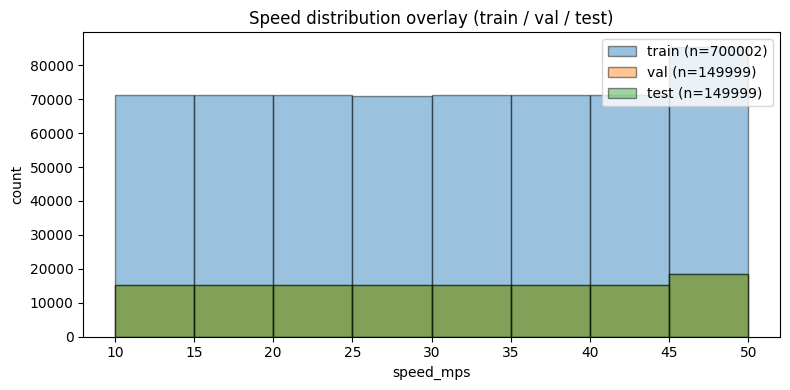

Saved speed histograms: speed_histograms_per_split.png, speed_histogram_overlay.png
[2026-05-31 20:04:52] [INFO] Dataset split histograms -> /home/skilliva/DopplerLab/experiments/test_dopplernet_sa_xpinn/results/dataset


  train: 700002 clips
  val  : 149999 clips


  test : 149999 clips
Speed range (m/s): -50.0 .. 50.0
Path types: ['bezier', 'parabola', 'straight']


Split fractions: train=70.0% val=15.0% test=15.0% (target 70%/15%/15%)
[2026-05-31 20:04:59] [INFO] Split leakage check PASSED — 1000000 clips, no overlap
Split integrity: PASSED (no train/val/test leakage)


In [8]:
# DopplerSim batch manifest: dataset.csv at batch root + audio_clips/sample_*/Common|cqt.npy
WAV_NAME_RE = re.compile(
    r"^(?P<vehicle>[A-Za-z0-9]+)_(?P<path>straight|parabola|bezier|miss)_"
    r"(?P<direction>left_to_right|right_to_left)_"
    r"(?P<speed>\d+(?:\.\d+)?)mps_(?P<dist>[\d.]+)m_(?P<idx>\d+)\.wav$",
    re.IGNORECASE,
)
WAV_NAME_LEGACY_RE = re.compile(
    r"^(car_\d+)_(straight|parabola|bezier|miss)_(\d+)mps_(\d+)m_(\d+)\.wav$",
    re.IGNORECASE,
)


def parse_wav_metadata(wav_path: Path) -> Optional[Dict[str, Any]]:
    m = WAV_NAME_RE.match(wav_path.name)
    if m:
        g = m.groupdict()
        return {
            "vehicle_class": g["vehicle"],
            "path_type": g["path"].lower(),
            "direction_text": g["direction"].lower(),
            "speed_mps": float(g["speed"]),
            "cpa_distance_m": float(g["dist"]),
            "clip_idx": g["idx"],
        }
    m = WAV_NAME_LEGACY_RE.match(wav_path.name)
    if m:
        vehicle, path_type, speed_mps, distance_m, clip_idx = m.groups()
        return {
            "vehicle_class": vehicle,
            "path_type": path_type.lower(),
            "direction_text": "unknown",
            "speed_mps": float(speed_mps),
            "cpa_distance_m": float(distance_m),
            "clip_idx": clip_idx,
        }
    return None


def resolve_sample_feature_dir(sample_dir: Path) -> Path:
    """Locate cqt.npy under Common/Essential (or legacy flat sample folder)."""
    candidates = [CFG.feature_subdir, "Common", "Essential"]
    seen = set()
    for sub in candidates:
        if sub in seen:
            continue
        seen.add(sub)
        d = sample_dir / sub
        if (d / "cqt.npy").exists() or (d / "frequency.npy").exists():
            return d
    if (sample_dir / "cqt.npy").exists() or (sample_dir / "frequency.npy").exists():
        return sample_dir
    raise FileNotFoundError(f"No cqt.npy under {sample_dir}/{{{','.join(candidates)}}}")


def read_label_speed(sample_dir: Path) -> Optional[float]:
    label_path = sample_dir / CFG.b1_label_subdir / "label_speed.npy"
    if label_path.exists():
        return float(np.load(label_path))
    return None


def _manifest_row_from_parts(
    sample_id: str,
    sample_dir: Path,
    feat_dir: Path,
    batch_id: str,
    meta: Dict[str, Any],
) -> Dict[str, Any]:
    wav_path = ""
    wav_name = meta.get("filename")
    if wav_name:
        candidate = feat_dir / wav_name
        if CFG.verify_features_on_manifest:
            if candidate.exists():
                wav_path = str(candidate)
        else:
            wav_path = str(candidate)
    if not wav_path and CFG.verify_features_on_manifest:
        wav_files = sorted(feat_dir.glob("*.wav"))
        if not wav_files:
            wav_files = sorted(sample_dir.rglob("*.wav"))
        if wav_files:
            wav_path = str(wav_files[0])

    cpa_time = meta.get("cpa_time_sec", meta.get("cpa_time", 5.0))
    if cpa_time is None or (isinstance(cpa_time, float) and np.isnan(cpa_time)):
        cpa_time = 5.0
    cpa_dist = meta.get("cpa_distance_m", meta.get("cpa_distance", 0.0))
    if cpa_dist is None or (isinstance(cpa_dist, float) and np.isnan(cpa_dist)):
        cpa_dist = 0.0

    path_type = str(meta.get("path_type") or meta.get("trajectory_type", "unknown")).lower()
    motion = str(meta.get("motion_scenario", "pass_by"))
    if motion == "pass_by":
        motion = "passby"

    return {
        "clip_id": sample_id,
        "sample_dir": str(sample_dir),
        "feature_dir": str(feat_dir),
        "wav_path": wav_path,
        "batch_id": str(meta.get("batch_id", batch_id)),
        "vehicle_class": str(meta.get("vehicle_class", meta.get("vehicle", "unknown"))),
        "path_type": path_type,
        "direction_text": str(meta.get("direction_text", "unknown")),
        "speed_mps": float(meta.get("speed_mps", meta.get("speed", 0.0))),
        "acceleration_mps2": float(meta.get("acceleration", meta.get("acceleration_mps2", 0.0)) or 0.0),
        "cpa_distance_m": float(cpa_dist),
        "cpa_time_sec": float(cpa_time),
        "motion_scenario": motion,
        "pass_by_in_clip": bool(meta.get("pass_by_in_clip", True)),
        "is_crossing": bool(meta.get("is_crossing", False)),
    }


def _infer_feature_dir(sample_dir: Path) -> Path:
    """Construct expected feature path without filesystem traversal (manifest-first)."""
    return sample_dir / CFG.feature_subdir


def batch_manifest_fingerprint(batch_root: Path) -> Dict[str, Any]:
    """Lightweight batch-root manifest signature for cache invalidation."""
    fp: Dict[str, Any] = {"batch_root": str(batch_root.resolve())}
    csv_path = batch_root / CFG.dataset_csv
    if csv_path.exists():
        st = csv_path.stat()
        fp["dataset_csv"] = {"size": int(st.st_size), "mtime_ns": int(st.st_mtime_ns)}
    progress_path = batch_root / "progress.json"
    if progress_path.exists():
        try:
            fp["progress"] = json.loads(progress_path.read_text(encoding="utf-8"))
        except (json.JSONDecodeError, OSError):
            fp["progress"] = {"readable": False}
    meta_files = sorted(batch_root.glob("metadata_*.json"))
    if meta_files:
        st = meta_files[0].stat()
        fp["metadata_json"] = {
            "name": meta_files[0].name,
            "size": int(st.st_size),
            "mtime_ns": int(st.st_mtime_ns),
        }
    return fp


def resolve_manifest_source(batch_root: Path) -> str:
    """Pick fastest trustworthy manifest source without scanning audio_clips/."""
    forced = CFG.manifest_source
    if forced != "auto":
        return forced

    csv_path = batch_root / CFG.dataset_csv
    progress_path = batch_root / "progress.json"
    meta_files = sorted(batch_root.glob("metadata_*.json"))

    n_progress = None
    if progress_path.exists():
        try:
            n_progress = int(json.loads(progress_path.read_text(encoding="utf-8")).get("generated_so_far", 0))
        except (json.JSONDecodeError, OSError, TypeError, ValueError):
            n_progress = None

    if meta_files and n_progress and n_progress <= CFG.manifest_json_max_clips:
        try:
            batch_meta = json.loads(meta_files[0].read_text(encoding="utf-8"))
            n_meta = len(batch_meta.get("clips", []))
            if n_meta > 0 and n_meta == n_progress:
                return "metadata_json"
        except (json.JSONDecodeError, OSError):
            pass

    if csv_path.exists():
        return "dataset_csv"

    if meta_files:
        return "metadata_json"

    return "scan"


def validate_manifest_spot_check(manifest_df: pd.DataFrame, n: int) -> None:
    """Random cqt.npy existence checks — cheap integrity guard without full scan."""
    if n <= 0 or len(manifest_df) == 0:
        return
    rng = np.random.default_rng(CFG.seed)
    pick = manifest_df if len(manifest_df) <= n else manifest_df.sample(n=n, random_state=CFG.seed)
    missing = []
    for _, row in pick.iterrows():
        feat = Path(row["feature_dir"])
        cqt = feat / "cqt.npy"
        if not cqt.exists():
            missing.append(row["clip_id"])
    if missing:
        raise FileNotFoundError(
            f"Manifest spot-check failed ({len(missing)}/{len(pick)}): missing cqt.npy e.g. {missing[:3]}. "
            "Set verify_features_on_manifest=True for full scan or REFRESH_SETUP_CACHE=True."
        )
    print(f"Manifest spot-check: {len(pick)} clips OK (cqt.npy present)")


def _manifest_row_from_csv_dict(
    sample_id: str,
    sample_dir: Path,
    feat_dir: Path,
    batch_id: str,
    meta: Dict[str, Any],
) -> Dict[str, Any]:
    if "path_type" not in meta or pd.isna(meta.get("path_type")):
        meta = dict(meta)
        meta["path_type"] = meta.get("trajectory_type", "unknown")
    return _manifest_row_from_parts(sample_id, sample_dir, feat_dir, batch_id, meta)


def load_manifest_from_dataset_csv(batch_root: Path) -> pd.DataFrame:
    csv_path = batch_root / CFG.dataset_csv
    clips_root = batch_root / CFG.audio_clips_subdir
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing {csv_path}")

    if CFG.test_mode:
        raw = pd.read_csv(csv_path, nrows=CFG.test_csv_scan_rows)
        print(f"TEST mode: scanning first {len(raw)} CSV rows (cap={CFG.test_csv_scan_rows})")
    else:
        raw = pd.read_csv(csv_path)
    batch_id = batch_root.name
    rows = []
    skipped = 0
    t0 = time.perf_counter()

    for _, row in raw.iterrows():
        sample_id = str(row["sample_id"])
        sample_dir = clips_root / sample_id
        meta = row.to_dict()

        if CFG.verify_features_on_manifest:
            if not sample_dir.is_dir():
                skipped += 1
                continue
            try:
                feat_dir = resolve_sample_feature_dir(sample_dir)
            except FileNotFoundError:
                skipped += 1
                continue
            if pd.isna(meta.get("speed_mps")):
                label_speed = read_label_speed(sample_dir)
                if label_speed is not None:
                    meta["speed_mps"] = label_speed
        else:
            feat_dir = _infer_feature_dir(sample_dir)

        rows.append(_manifest_row_from_csv_dict(
            sample_id, sample_dir, feat_dir, batch_id, meta,
        ))

    if not rows:
        raise FileNotFoundError(f"No usable clips from {csv_path} under {clips_root}")
    elapsed = time.perf_counter() - t0
    mode = "verified" if CFG.verify_features_on_manifest else "manifest-first"
    if skipped:
        print(f"Skipped {skipped} CSV rows (missing sample folder or cqt.npy).")
    print(f"Loaded manifest from {csv_path.name}: {len(rows)} clips ({mode}, {elapsed:.2f}s)")
    return pd.DataFrame(rows)


def load_manifest_from_metadata_json(batch_root: Path) -> pd.DataFrame:
    """Primary fast path: DopplerSim metadata_*.json clips[] — no audio_clips scan."""
    meta_files = sorted(batch_root.glob("metadata_*.json"))
    if not meta_files:
        raise FileNotFoundError(f"No metadata_*.json under {batch_root}")

    t0 = time.perf_counter()
    batch_meta = json.loads(meta_files[0].read_text(encoding="utf-8"))
    batch_id = str(batch_meta.get("batch_id", batch_root.name))
    clips_root = batch_root / CFG.audio_clips_subdir
    clips = batch_meta.get("clips", [])
    rows = []
    skipped = 0

    for clip in clips:
        sample_id = str(clip.get("sample_dir") or f"sample_{int(clip.get('index', 0)):07d}")
        sample_dir = clips_root / sample_id
        labels = clip.get("labels") or {}
        params = clip.get("parameters") or {}

        if CFG.verify_features_on_manifest:
            if not sample_dir.is_dir():
                skipped += 1
                continue
            try:
                feat_dir = resolve_sample_feature_dir(sample_dir)
            except FileNotFoundError:
                skipped += 1
                continue
        else:
            feat_dir = _infer_feature_dir(sample_dir)

        meta: Dict[str, Any] = {
            "filename": clip.get("filename", ""),
            "batch_id": batch_id,
            "vehicle_class": labels.get("vehicle_class", clip.get("vehicle", "unknown")),
            "trajectory_type": labels.get("trajectory_type", clip.get("path_type", "unknown")),
            "path_type": labels.get("trajectory_type", clip.get("path_type", "unknown")),
            "direction_text": labels.get("direction_text", clip.get("direction_text", "unknown")),
            "speed_mps": labels.get(
                "speed_mps", params.get("speed", clip.get("parameters", {}).get("speed")),
            ),
            "acceleration": labels.get("acceleration_mps2", clip.get("acceleration", 0.0)),
            "cpa_distance_m": labels.get("cpa_distance_m", params.get("distance")),
            "cpa_time_sec": labels.get("cpa_time_sec", params.get("cpa_time_sec", params.get("cpa_time"))),
            "pass_by_in_clip": labels.get("pass_by_in_clip", clip.get("pass_by_in_clip", True)),
            "is_crossing": labels.get("is_crossing", False),
            "motion_scenario": labels.get("motion_scenario", "pass_by"),
        }
        rows.append(_manifest_row_from_csv_dict(
            sample_id, sample_dir, feat_dir, batch_id, meta,
        ))

    if not rows:
        raise FileNotFoundError(f"No clips in {meta_files[0].name}")
    elapsed = time.perf_counter() - t0
    mode = "verified" if CFG.verify_features_on_manifest else "manifest-first"
    if skipped:
        print(f"Skipped {skipped} metadata clips (missing on disk).")
    print(
        f"Loaded manifest from {meta_files[0].name}: {len(rows)} clips "
        f"({mode}, {elapsed:.2f}s)"
    )
    return pd.DataFrame(rows)


def scan_batch_clips(clips_root: Path, batch_id: str = "unknown") -> pd.DataFrame:
    """Fallback when dataset.csv is absent: walk audio_clips/sample_* folders."""
    rows = []
    skipped = 0
    for sample_dir in sorted(clips_root.glob("sample_*")):
        if not sample_dir.is_dir():
            continue
        try:
            feat_dir = resolve_sample_feature_dir(sample_dir)
        except FileNotFoundError:
            skipped += 1
            continue

        meta: Dict[str, Any] = {"batch_id": batch_id}
        label_speed = read_label_speed(sample_dir)
        if label_speed is not None:
            meta["speed_mps"] = label_speed

        wav_files = sorted(feat_dir.glob("*.wav"))
        if wav_files:
            meta["filename"] = wav_files[0].name
            parsed = parse_wav_metadata(wav_files[0])
            if parsed:
                meta.update(parsed)
        if "speed_mps" not in meta:
            skipped += 1
            continue

        rows.append(_manifest_row_from_parts(
            sample_dir.name, sample_dir, feat_dir, batch_id, meta,
        ))

    if not rows:
        raise FileNotFoundError(f"No sample_* folders with cqt.npy under {clips_root}")
    if skipped:
        print(f"Skipped {skipped} sample folders (missing features or labels).")
    return pd.DataFrame(rows)


def load_batch_manifest(batch_root: Path) -> pd.DataFrame:
    source = resolve_manifest_source(batch_root)
    print(f"Manifest source: {source}")

    if source == "metadata_json":
        manifest_df = load_manifest_from_metadata_json(batch_root)
    elif source == "dataset_csv":
        manifest_df = load_manifest_from_dataset_csv(batch_root)
    else:
        clips_root = batch_root / CFG.audio_clips_subdir
        batch_id = batch_root.name
        meta_files = sorted(batch_root.glob("metadata_*.json"))
        if meta_files:
            try:
                batch_id = json.loads(meta_files[0].read_text(encoding="utf-8")).get("batch_id", batch_id)
            except (json.JSONDecodeError, OSError):
                pass
        print(f"WARN: falling back to audio_clips scan under {clips_root}")
        manifest_df = scan_batch_clips(clips_root, batch_id=batch_id)

    if not CFG.verify_features_on_manifest and CFG.manifest_spot_check_n > 0:
        validate_manifest_spot_check(manifest_df, CFG.manifest_spot_check_n)
    return manifest_df


def _split_counts(n: int, train_frac: float, val_frac: float, test_frac: float) -> Tuple[int, int, int]:
    """Allocate n clips to train/val/test; every split with frac>0 gets >=1 clip when n>=3."""
    if n <= 0:
        return 0, 0, 0
    if n == 1:
        return 1, 0, 0
    if n == 2:
        return 1, 0, 1 if test_frac > 0 else 0

    n_test = int(round(n * test_frac))
    n_val = int(round(n * val_frac))
    if test_frac > 0 and n >= 3:
        n_test = max(1, n_test)
    if val_frac > 0 and n >= 3:
        n_val = max(1, n_val)
    n_train = n - n_val - n_test
    while n_train < 1 and (n_val > 0 or n_test > 0):
        if n_val >= n_test and n_val > 0:
            n_val -= 1
        elif n_test > 0:
            n_test -= 1
        n_train = n - n_val - n_test
    return n_train, n_val, n_test


def speed_bin_label(speed: float, edges: Tuple[float, ...]) -> str:
    """Map speed (m/s) to a human-readable bin label, e.g. 10-15."""
    edges = tuple(float(e) for e in edges)
    speed = float(speed)
    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i + 1]
        if i == len(edges) - 2:
            if lo <= speed <= hi:
                return f"{lo:g}-{hi:g}"
        elif lo <= speed < hi:
            return f"{lo:g}-{hi:g}"
    if speed < edges[0]:
        return f"{edges[0]:g}-{edges[1]:g}"
    return f"{edges[-2]:g}-{edges[-1]:g}"


def ordered_speed_bin_labels(edges: Tuple[float, ...]) -> List[str]:
    edges = tuple(float(e) for e in edges)
    return [f"{edges[i]:g}-{edges[i + 1]:g}" for i in range(len(edges) - 1)]


def add_speed_bins(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["speed_bin"] = df["speed_mps"].astype(float).apply(
        lambda s: speed_bin_label(s, CFG.speed_bin_edges)
    )
    return df




def subset_manifest_for_test(manifest_df: pd.DataFrame, n: int) -> pd.DataFrame:
    """Pick n clips across speed bins for leakage-safe smoke (n>=3 -> 1 train / 1 val / 1 test)."""
    n = max(1, int(n))
    if len(manifest_df) <= n:
        out = manifest_df.copy()
    else:
        df = add_speed_bins(manifest_df.copy())
        picked_idx: List[int] = []
        rng = np.random.default_rng(CFG.seed)
        for _, group in df.groupby("speed_bin", sort=False):
            if len(picked_idx) >= n:
                break
            idx = list(group.index)
            rng.shuffle(idx)
            picked_idx.append(idx[0])
        if len(picked_idx) < n:
            rest = [i for i in df.index if i not in picked_idx]
            rng.shuffle(rest)
            picked_idx.extend(rest[: n - len(picked_idx)])
        out = manifest_df.loc[picked_idx[:n]].copy()
    print(
        f"TEST mode: {len(out)} clip(s) selected for smoke run "
        f"(same stratified split + leakage checks as full training)"
    )
    return out.reset_index(drop=True)


def apply_test_mode_manifest(manifest_df: pd.DataFrame) -> pd.DataFrame:
    if not CFG.test_mode:
        return manifest_df
    return subset_manifest_for_test(manifest_df, CFG.test_n_clips)

def assign_speed_stratified_split(df: pd.DataFrame) -> pd.DataFrame:
    """Scene-level split (one clip_id/sample_dir per scene) stratified by speed bin.

    Within each speed bin, clips are shuffled and allocated ~70/15/15 to train/val/test.
    Each scene appears in exactly one split — no audio or metadata leakage.
    """
    total = CFG.train_frac + CFG.val_frac + CFG.test_frac
    if not math.isclose(total, 1.0, rel_tol=1e-4):
        raise ValueError(f"train/val/test fractions must sum to 1.0 (got {total:.4f})")

    df = add_speed_bins(df)
    df["split"] = ""
    test_batches = set(CFG.test_batch_ids)
    val_batches = set(CFG.val_batch_ids)

    if test_batches:
        df.loc[df["batch_id"].isin(test_batches), "split"] = "test"
    if val_batches:
        df.loc[df["batch_id"].isin(val_batches) & (df["split"] != "test"), "split"] = "val"

    rng = np.random.default_rng(CFG.seed)
    pending = df.index[df["split"] == ""]

    for bin_label, group in df.loc[pending].groupby("speed_bin", sort=False):
        idx = list(group.index)
        rng.shuffle(idx)
        n_tr, n_va, n_te = _split_counts(len(idx), CFG.train_frac, CFG.val_frac, CFG.test_frac)
        labels = ["train"] * n_tr + ["val"] * n_va + ["test"] * n_te
        for row_i, split_name in zip(idx, labels):
            df.at[row_i, "split"] = split_name

    if (df["split"] == "").any():
        raise RuntimeError("Some clips were not assigned a split.")

    print(
        f"Speed-stratified split (bins={list(CFG.speed_bin_edges)}): "
        f"train={CFG.train_frac:.0%} val={CFG.val_frac:.0%} test={CFG.test_frac:.0%}"
    )
    if test_batches or val_batches:
        print(f"Batch overrides: test={sorted(test_batches)} val={sorted(val_batches)}")
    return df


def build_speed_bin_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for label in ordered_speed_bin_labels(CFG.speed_bin_edges):
        row = {"Speed Bin": label}
        for split in ("train", "val", "test"):
            mask = (df["speed_bin"] == label) & (df["split"] == split)
            row[f"{split.title()} Count"] = int(mask.sum())
        rows.append(row)
    return pd.DataFrame(rows)


def print_speed_split_summary(df: pd.DataFrame) -> None:
    print("\n=== Speed split summary ===")
    for split in ("train", "val", "test"):
        s = df.loc[df["split"] == split, "speed_mps"].astype(float)
        print(
            f"  {split:5s}: n={len(s):4d}  min={s.min():5.1f}  max={s.max():5.1f}  "
            f"mean={s.mean():6.2f}  median={s.median():6.2f}  std={s.std():5.2f}"
        )


def verify_speed_bin_coverage(df: pd.DataFrame) -> Dict[str, Any]:
    """Verify every speed bin has samples in train/val/test when enough clips exist."""
    table = build_speed_bin_table(df)
    missing = {split: [] for split in ("train", "val", "test")}
    for _, row in table.iterrows():
        label = row["Speed Bin"]
        total_in_bin = int(row["Train Count"] + row["Val Count"] + row["Test Count"])
        for split in ("train", "val", "test"):
            col = f"{split.title()} Count"
            if total_in_bin >= 3 and int(row[col]) == 0:
                missing[split].append(label)
            elif total_in_bin == 2 and split == "val" and int(row[col]) == 0:
                print(f"WARN: speed bin {label} has only 2 clips — val may be empty by design")
            elif total_in_bin == 1 and split in ("val", "test") and int(row[col]) == 0:
                print(f"WARN: speed bin {label} has only 1 clip — assigned to train only")
    for split, bins in missing.items():
        if bins:
            print(f"WARN: {split} missing speed bins (bin had >=3 clips): {bins}")
    return {"speed_bin_table": table, "missing_bins": missing}


def plot_speed_split_histograms(df: pd.DataFrame, save_dir: Path) -> None:
    """Per-split histograms, combined overlay, and speed-bin table plot."""
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    edges = list(CFG.speed_bin_edges)
    hist_range = (edges[0], edges[-1])
    splits = ("train", "val", "test")
    colors = {"train": "#1f77b4", "val": "#ff7f0e", "test": "#2ca02c"}

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    for ax, split in zip(axes, splits):
        part = df.loc[df["split"] == split, "speed_mps"].astype(float)
        ax.hist(part, bins=edges, range=hist_range, edgecolor="k", alpha=0.75, color=colors[split])
        ax.set_title(f"{split} speeds (m/s)  n={len(part)}")
        ax.set_xlabel("speed_mps")
        ax.set_ylabel("count")
    plt.tight_layout()
    per_split_path = save_dir / "speed_histograms_per_split.png"
    save_figure(fig, per_split_path)

    fig, ax = plt.subplots(figsize=(8, 4))
    for split in splits:
        part = df.loc[df["split"] == split, "speed_mps"].astype(float)
        ax.hist(
            part, bins=edges, range=hist_range, alpha=0.45, label=f"{split} (n={len(part)})",
            edgecolor="k", color=colors[split],
        )
    ax.set_xlabel("speed_mps")
    ax.set_ylabel("count")
    ax.set_title("Speed distribution overlay (train / val / test)")
    ax.legend()
    plt.tight_layout()
    overlay_path = save_dir / "speed_histogram_overlay.png"
    save_figure(fig, overlay_path)
    print(f"Saved speed histograms: {per_split_path.name}, {overlay_path.name}")



def assert_split_no_leakage(df: pd.DataFrame) -> None:
    """Hard-fail if train/val/test share any scene (clip_id or sample_dir)."""
    verify_split_integrity(df)
    for col in ("clip_id", "sample_dir"):
        parts = {s: set(df.loc[df["split"] == s, col].astype(str)) for s in ("train", "val", "test")}
        for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
            overlap = parts[a] & parts[b]
            if overlap:
                raise RuntimeError(
                    f"SPLIT LEAKAGE on {col}: {len(overlap)} shared between {a}/{b}, "
                    f"e.g. {sorted(overlap)[:5]}"
                )
    n = len(df)
    if (df["split"] == "").any():
        raise RuntimeError("Some clips have empty split assignment")
    fr = {s: float((df["split"] == s).mean()) for s in ("train", "val", "test")}
    print(
        f"Split fractions: train={fr['train']:.1%} val={fr['val']:.1%} test={fr['test']:.1%} "
        f"(target {CFG.train_frac:.0%}/{CFG.val_frac:.0%}/{CFG.test_frac:.0%})"
    )
    run_log(f"Split leakage check PASSED — {n} clips, no overlap")


def save_split_indices(manifest_df: pd.DataFrame, data_root: Path) -> Path:
    """Persist exact clip partition for reproducible future runs."""
    out = SETUP_CACHE_DIR / CFG.split_indices_file
    table = build_speed_bin_table(manifest_df)
    payload = {
        "version": "speed_stratified_v1",
        "fingerprint": setup_cache_fingerprint(data_root),
        "seed": CFG.seed,
        "speed_bin_edges": list(CFG.speed_bin_edges),
        "train_frac": CFG.train_frac,
        "val_frac": CFG.val_frac,
        "test_frac": CFG.test_frac,
        "train_clip_ids": sorted(manifest_df.loc[manifest_df["split"] == "train", "clip_id"].astype(str).tolist()),
        "val_clip_ids": sorted(manifest_df.loc[manifest_df["split"] == "val", "clip_id"].astype(str).tolist()),
        "test_clip_ids": sorted(manifest_df.loc[manifest_df["split"] == "test", "clip_id"].astype(str).tolist()),
        "speed_bin_table": table.to_dict(orient="records"),
    }
    _atomic_write_bytes(out, json.dumps(payload, indent=2).encode("utf-8"))
    print(f"Saved split indices: {out}")
    return out


def load_split_indices(data_root: Path) -> Optional[Dict[str, Any]]:
    out = SETUP_CACHE_DIR / CFG.split_indices_file
    if not out.exists():
        return None
    payload = json.loads(out.read_text(encoding="utf-8"))
    if payload.get("fingerprint") != setup_cache_fingerprint(data_root):
        print("Split indices stale (fingerprint mismatch); will recompute split.")
        return None
    return payload


def apply_saved_split(df: pd.DataFrame, payload: Dict[str, Any]) -> pd.DataFrame:
    split_map: Dict[str, str] = {}
    for split in ("train", "val", "test"):
        for cid in payload.get(f"{split}_clip_ids", []):
            split_map[str(cid)] = split
    df = add_speed_bins(df)
    df = df.copy()
    df["split"] = df["clip_id"].astype(str).map(split_map)
    unknown = df["split"].isna()
    if unknown.any():
        missing = df.loc[unknown, "clip_id"].head(5).tolist()
        raise RuntimeError(
            f"Saved split missing {int(unknown.sum())} clip(s) present in manifest, e.g. {missing}"
        )
    print(f"Applied saved split indices ({CFG.split_indices_file})")
    return df


def verify_split_integrity(df: pd.DataFrame) -> Dict[str, Any]:
    """Hard checks: disjoint scenes (clip_id + sample_dir); speed-bin coverage."""
    parts = {s: df[df["split"] == s] for s in ("train", "val", "test")}
    clip_sets = {s: set(parts[s]["clip_id"].astype(str)) for s in parts}
    dir_sets = {s: set(parts[s]["sample_dir"].astype(str)) for s in parts}

    for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
        overlap = clip_sets[a] & clip_sets[b]
        assert not overlap, f"clip_id overlap between {a} and {b}: {sorted(overlap)[:5]}"
        overlap_dir = dir_sets[a] & dir_sets[b]
        assert not overlap_dir, f"sample_dir overlap between {a} and {b}: {sorted(overlap_dir)[:5]}"

    assert sum(len(clip_sets[s]) for s in clip_sets) == len(df), "split partition does not cover all clips"

    bin_cov = verify_speed_bin_coverage(df)
    return {"clip_counts": {s: len(clip_sets[s]) for s in clip_sets}, "speed_bins": bin_cov}


def print_split_balance_report(df: pd.DataFrame) -> None:
    """Speed-bin balance table and split fractions."""
    print("\n=== Split balance report ===")
    print("| Check | Status |")
    print("|-------|--------|")
    print("| Scene leakage | NO — disjoint clip_id / sample_dir (one scene per folder) |")
    print("| Split method | Speed-stratified regression (~70/15/15 within each speed bin) |")

    n = len(df)
    for split in ("train", "val", "test"):
        cnt = int((df["split"] == split).sum())
        print(f"| {split:5s} size | {cnt} clips ({100.0 * cnt / n:.1f}%) |")

    table = build_speed_bin_table(df)
    print("\nSpeed bin coverage (target: all splits represented when bin has >=3 clips):")
    print(table.to_string(index=False))

    print("\nFraction of each speed bin in train / val / test:")
    fr_rows = []
    for _, row in table.iterrows():
        total = row["Train Count"] + row["Val Count"] + row["Test Count"]
        if total <= 0:
            continue
        fr_rows.append({
            "Speed Bin": row["Speed Bin"],
            "train": row["Train Count"] / total,
            "val": row["Val Count"] / total,
            "test": row["Test Count"] / total,
        })
    if fr_rows:
        print(pd.DataFrame(fr_rows).round(2).to_string(index=False))


# Setup cache — persist manifest + splits under EXP_ROOT/setup_cache (survives Colab restarts on Drive)
SETUP_MANIFEST_CACHE = SETUP_CACHE_DIR / "manifest.pkl"
SETUP_SAMPLES_CACHE = SETUP_CACHE_DIR / "samples.pkl"
SETUP_META_FILE = SETUP_CACHE_DIR / "setup_meta.json"


def setup_cache_fingerprint(data_root: Path) -> str:
    payload = json.dumps(
        {
            "data_root": str(data_root.resolve()),
            "dataset_csv": CFG.dataset_csv,
            "audio_clips_subdir": CFG.audio_clips_subdir,
            "feature_subdir": CFG.feature_subdir,
            "seed": CFG.seed,
            "train_frac": CFG.train_frac,
            "val_frac": CFG.val_frac,
            "test_frac": CFG.test_frac,
            "speed_bin_edges": list(CFG.speed_bin_edges),
            "split_method": "speed_stratified",
            "batch_manifest": batch_manifest_fingerprint(data_root),
            "manifest_source": CFG.manifest_source,
            "verify_features_on_manifest": CFG.verify_features_on_manifest,
            "val_batch_ids": list(CFG.val_batch_ids),
            "test_batch_ids": list(CFG.test_batch_ids),
            "input_mode": CFG.input_mode,
            "cqt_per_bin_norm": CFG.cqt_per_bin_norm,
            "multitask_aux": CFG.multitask_aux,
            "xpinn_enabled": CFG.xpinn_enabled,
            "attn_d_model": CFG.attn_d_model,
            "test_mode": CFG.test_mode,
            "test_n_clips": CFG.test_n_clips,
        },
        sort_keys=True,
    )
    return hashlib.sha256(payload.encode()).hexdigest()[:16]


def _atomic_write_bytes(path: Path, data: bytes) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_bytes(data)
    tmp.replace(path)


def save_setup_meta(data_root: Path, manifest_df: pd.DataFrame, has_samples: bool = False) -> None:
    meta = {
        "fingerprint": setup_cache_fingerprint(data_root),
        "data_root": str(data_root.resolve()),
        "n_clips": int(len(manifest_df)),
        "has_samples": bool(has_samples),
        "saved_at": time.time(),
    }
    _atomic_write_bytes(SETUP_META_FILE, json.dumps(meta, indent=2).encode("utf-8"))


def save_setup_manifest(manifest_df: pd.DataFrame, data_root: Path) -> None:
    _atomic_write_bytes(SETUP_MANIFEST_CACHE, pickle.dumps(manifest_df, protocol=pickle.HIGHEST_PROTOCOL))
    save_setup_meta(data_root, manifest_df, has_samples=SETUP_SAMPLES_CACHE.exists())


def load_setup_manifest(data_root: Path) -> Optional[pd.DataFrame]:
    refresh = globals().get("REFRESH_SETUP_CACHE", False)
    if CFG.test_mode or refresh or not SETUP_MANIFEST_CACHE.exists() or not SETUP_META_FILE.exists():
        return None
    meta = json.loads(SETUP_META_FILE.read_text(encoding="utf-8"))
    if meta.get("fingerprint") != setup_cache_fingerprint(data_root):
        print("Setup cache stale (split config or data root changed); rescanning dataset.")
        return None
    if meta.get("data_root") != str(data_root.resolve()):
        print("Setup cache stale (data root path changed); rescanning dataset.")
        return None
    manifest_df = pickle.loads(SETUP_MANIFEST_CACHE.read_bytes())
    print(
        f"Loaded manifest from setup cache: {len(manifest_df)} clips "
        f"(saved {time.strftime('%Y-%m-%d %H:%M', time.localtime(meta.get('saved_at', 0)))})"
    )
    return manifest_df


_manifest_cached = load_setup_manifest(BATCH_ROOT)
_saved_split = None if CFG.test_mode else load_split_indices(BATCH_ROOT)

if _manifest_cached is not None:
    manifest_df = apply_test_mode_manifest(_manifest_cached)
    if _saved_split is None:
        save_split_indices(manifest_df, BATCH_ROOT)
elif _saved_split is not None:
    manifest_df = load_batch_manifest(BATCH_ROOT)
    manifest_df = apply_test_mode_manifest(manifest_df)
    manifest_df = apply_saved_split(manifest_df, _saved_split)
    save_setup_manifest(manifest_df, BATCH_ROOT)
    print(f"Saved manifest to {SETUP_MANIFEST_CACHE}")
else:
    manifest_df = load_batch_manifest(BATCH_ROOT)
    manifest_df = apply_test_mode_manifest(manifest_df)
    manifest_df = assign_speed_stratified_split(manifest_df)
    save_split_indices(manifest_df, BATCH_ROOT)
    save_setup_manifest(manifest_df, BATCH_ROOT)
    print(f"Saved manifest to {SETUP_MANIFEST_CACHE}")

if "split" not in manifest_df.columns or (manifest_df["split"] == "").any():
    raise RuntimeError("Manifest missing split assignments — rerun setup with REFRESH_SETUP_CACHE=True")

split_checks = verify_split_integrity(manifest_df)
print_split_balance_report(manifest_df)
print_speed_split_summary(manifest_df)
plot_speed_split_histograms(manifest_df, RESULTS_DATASET_DIR)
run_log(f"Dataset split histograms -> {RESULTS_DATASET_DIR}")
for split_name in ("train", "val", "test"):
    print(f"  {split_name:5s}: {(manifest_df['split'] == split_name).sum()} clips")
print(f"Speed range (m/s): {manifest_df['speed_mps'].min():.1f} .. {manifest_df['speed_mps'].max():.1f}")
print(f"Path types: {sorted(manifest_df['path_type'].unique())}")
assert_split_no_leakage(manifest_df)
print("Split integrity: PASSED (no train/val/test leakage)")


In [9]:
# Feature loading: cqt.npy under sample_*/Common/ (or Essential); labels from dataset.csv / B1_Speed/
# Lazy load at batch time (avoids duplicating every CQT in RAM during build_samples)
from collections import OrderedDict
from concurrent.futures import ThreadPoolExecutor
from queue import Queue
from threading import Thread

_FEATURE_CACHE: "OrderedDict[str, np.ndarray]" = OrderedDict()
_FEATURE_CACHE_MAX = 4096


def _fit_time_frames(arr: np.ndarray, target_t: int) -> np.ndarray:
    if arr.ndim == 1:
        arr = arr[None, :]
    t = arr.shape[-1]
    if t < target_t:
        return np.pad(arr, ((0, 0), (0, target_t - t)))
    return arr[..., :target_t]


def normalize_cqt_per_bin(cqt: np.ndarray, eps: Optional[float] = None) -> np.ndarray:
    """DopplerNet 2D: z-score each frequency bin over time (numpy loader; model stays JAX)."""
    eps = CFG.cqt_norm_eps if eps is None else eps
    cqt = np.nan_to_num(cqt.astype(np.float32), copy=False)
    mean = cqt.mean(axis=1, keepdims=True)
    std = cqt.std(axis=1, keepdims=True) + eps
    return (cqt - mean) / std


def load_ridge_1d(root: Path) -> np.ndarray:
    """DopplerNet 1D ridge stack: dfdt, dfdt2, sign, freq_norm, rms, topk, t_rel."""
    t = CFG.n_time_frames
    freq = _fit_time_frames(np.load(root / "frequency.npy").astype(np.float32).reshape(-1), t)
    dfdt = _fit_time_frames(np.load(root / "dfdt.npy").astype(np.float32).reshape(-1), t)
    rms_path = root / "rms.npy"
    rms = (
        _fit_time_frames(np.load(rms_path).astype(np.float32).reshape(-1), t)
        if rms_path.exists()
        else np.zeros(t, dtype=np.float32)
    )
    topk_path = root / "spec_topk.npy"
    if topk_path.exists():
        topk = np.load(topk_path).astype(np.float32)
        topk = topk.reshape(topk.shape[0], -1)[..., 0] if topk.ndim > 1 else topk.reshape(-1)
        topk = _fit_time_frames(topk, t)
    else:
        topk = freq.copy()
    dfdt2 = np.gradient(dfdt)
    dfdt2 = dfdt2 / (float(dfdt2.std()) + 1e-8)
    sign_dfdt = np.sign(dfdt)
    fmin, fmax = float(freq.min()), float(freq.max())
    freq_norm = (freq - fmin) / (fmax - fmin + 1e-8)
    t_rel = np.linspace(-1.0, 1.0, t, dtype=np.float32)
    return np.stack([dfdt, dfdt2, sign_dfdt, freq_norm, rms, topk, t_rel], axis=0).astype(np.float32)


def stack_features(xs: List[np.ndarray]) -> np.ndarray:
    """Batch numpy features into model input layout."""
    mode = CFG.input_mode
    stacked = np.stack(xs, axis=0)
    if mode in ("doppler_attn_2d", "phsweep_cqt", "cqt_2d"):
        return stacked[:, None, :, :].astype(np.float32)
    if mode == "doppler_ridge_1d":
        return stacked.astype(np.float32)  # B, 7, T
    if mode == "frequency_only":
        return stacked.astype(np.float32)
    return np.transpose(stacked, (0, 3, 1, 2)).astype(np.float32)  # multi_hop: B, C, H, W


def prepare_model_input(x_np: np.ndarray) -> np.ndarray:
    """Single-sample feature array -> channel-first layout for predict_single."""
    mode = CFG.input_mode
    if mode in ("doppler_attn_2d", "phsweep_cqt", "cqt_2d"):
        return x_np[None, ...] if x_np.ndim == 2 else x_np
    if mode in ("frequency_only", "doppler_ridge_1d"):
        return x_np
    if x_np.ndim == 3 and x_np.shape[-1] == CFG.n_hops:
        return np.transpose(x_np, (2, 0, 1))
    return x_np


def load_features_from_sample(sample_dir: str, feature_dir: Optional[str] = None) -> np.ndarray:
    cache_key = feature_dir or sample_dir
    if cache_key in _FEATURE_CACHE:
        _FEATURE_CACHE.move_to_end(cache_key)
        return _FEATURE_CACHE[cache_key]

    root = Path(feature_dir) if feature_dir else resolve_sample_feature_dir(Path(sample_dir))
    if CFG.input_mode == "frequency_only":
        fpath = root / "frequency.npy"
        if not fpath.exists():
            alt = Path(sample_dir) / CFG.b1_label_subdir / "frequency.npy"
            fpath = alt if alt.exists() else fpath
        if not fpath.exists():
            raise FileNotFoundError(f"Missing frequency.npy under {root} or B1_Speed")
        arr = np.load(fpath).astype(np.float32)
        arr = _fit_time_frames(arr, CFG.n_time_frames)
        x = arr[None, :]
    elif CFG.input_mode == "doppler_ridge_1d":
        for name in ("frequency.npy", "dfdt.npy"):
            if not (root / name).exists():
                raise FileNotFoundError(f"Missing {root / name} for doppler_ridge_1d")
        x = load_ridge_1d(root)
    elif CFG.input_mode in ("doppler_attn_2d", "phsweep_cqt", "cqt_2d"):
        cqt_path = root / "cqt.npy"
        if not cqt_path.exists():
            raise FileNotFoundError(f"Missing {cqt_path}")
        cqt = np.asarray(np.load(cqt_path, mmap_mode="r"), dtype=np.float32)
        if cqt.ndim == 3:
            cqt = cqt.squeeze()
        cqt = _fit_time_frames(cqt, CFG.n_time_frames)
        if CFG.cqt_per_bin_norm:
            cqt = normalize_cqt_per_bin(cqt)
        x = cqt
    else:
        cqt_path = root / "cqt.npy"
        if not cqt_path.exists():
            raise FileNotFoundError(f"Missing {cqt_path}")
        cqt = np.asarray(np.load(cqt_path, mmap_mode="r"), dtype=np.float32)
        if cqt.ndim == 3:
            cqt = cqt.squeeze()
        cqt = _fit_time_frames(cqt, CFG.n_time_frames)
        if CFG.cqt_per_bin_norm:
            cqt = normalize_cqt_per_bin(cqt)
        x = np.stack([cqt] * CFG.n_hops, axis=-1)

    _FEATURE_CACHE[cache_key] = x
    while len(_FEATURE_CACHE) > getattr(CFG, "feature_cache_max", _FEATURE_CACHE_MAX):
        _FEATURE_CACHE.popitem(last=False)
    return x


def load_clip_arrays(row: pd.Series, split: str) -> Dict[str, np.ndarray]:
    x = load_features_from_sample(str(row["sample_dir"]), row.get("feature_dir"))
    return {
        "x": x.astype(np.float32),
        "speed_mps": np.float32(row["speed_mps"]),
        "meta": np.array([
            hash(str(row.get("path_type", ""))) % 1000,
            hash(str(row.get("vehicle_class", ""))) % 1000,
            hash(str(row.get("motion_scenario", ""))) % 1000,
            float(row.get("cpa_distance_m", 0)),
        ], dtype=np.float32),
    }


PATH_CLASS_TO_IDX = {name: i for i, name in enumerate(CFG.path_class_names)}


def path_type_to_idx(path_type: str) -> int:
    return PATH_CLASS_TO_IDX.get(str(path_type).lower().strip(), 0)


def apply_gain_augmentation(x: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """DopplerNet-style log-CQT gain jitter (train only)."""
    if not CFG.augment_gain:
        return x
    lo, hi = CFG.gain_jitter_range
    gain = rng.uniform(lo, hi)
    return (x * gain).astype(np.float32)


def build_samples(df: pd.DataFrame, desc: str = "Indexing clips") -> List[Dict[str, Any]]:
    """Store metadata only; CQT tensors load on demand in collate_numpy."""
    samples = []
    for idx, row in tqdm(df.reset_index(drop=True).iterrows(), total=len(df), desc=desc, leave=False):
        samples.append({
            "sample_dir": str(row["sample_dir"]),
            "feature_dir": str(row.get("feature_dir", row["sample_dir"])),
            "clip_id": str(row.get("clip_id", idx)),
            "speed_mps": float(row["speed_mps"]),
            "path_type": str(row.get("path_type", "simulated")),
            "path_idx": path_type_to_idx(row.get("path_type", "straight")),
            "vehicle_class": str(row.get("vehicle_class", "unknown")),
            "motion_scenario": str(row.get("motion_scenario", "passby")),
            "cpa_distance_m": float(row.get("cpa_distance_m", 0)),
            "cpa_time_sec": float(row.get("cpa_time_sec", 5.0)),
        })
    return samples


def apply_time_roll_1d(x: np.ndarray, rng: np.random.Generator, max_shift: int = 16) -> np.ndarray:
    """DopplerNet 1D: circular time shift on ridge channels (train only)."""
    shift = int(rng.integers(-max_shift, max_shift + 1))
    if shift == 0:
        return x
    return np.roll(x, shift, axis=-1).astype(np.float32)



def _load_batch_features(batch: List[Dict]) -> List[np.ndarray]:
    nw = max(1, int(getattr(CFG, "num_workers", 1)))
    if nw <= 1 or len(batch) <= 1:
        return [load_features_from_sample(b["sample_dir"], b.get("feature_dir")) for b in batch]
    with ThreadPoolExecutor(max_workers=min(nw, len(batch))) as pool:
        return list(pool.map(
            lambda b: load_features_from_sample(b["sample_dir"], b.get("feature_dir")),
            batch,
        ))


class PrefetchBatchIterator:
    def __init__(self, base: "BatchIterator", prefetch: int = 2):
        self.base = base
        self.prefetch = max(0, int(prefetch))

    def __len__(self) -> int:
        return len(self.base)

    def __iter__(self):
        if self.prefetch <= 0:
            yield from self.base
            return
        q: Queue = Queue(maxsize=self.prefetch)
        _sentinel = object()

        def _producer():
            try:
                for batch in self.base:
                    q.put(batch)
            finally:
                q.put(_sentinel)

        Thread(target=_producer, daemon=True).start()
        while True:
            item = q.get()
            if item is _sentinel:
                break
            yield item


def _wrap_loader(loader: BatchIterator, prefetch: int):
    if prefetch <= 0:
        return loader
    return PrefetchBatchIterator(loader, prefetch=prefetch)


def collate_numpy(batch: List[Dict], *, augment: bool = False, rng: Optional[np.random.Generator] = None) -> Dict[str, Any]:
    xs = _load_batch_features(batch)
    x = stack_features(xs)
    if augment:
        rng = rng or np.random.default_rng()
        if CFG.input_mode in ("doppler_attn_2d", "phsweep_cqt", "cqt_2d", "multi_hop_cqt"):
            x = apply_gain_augmentation(x, rng)
    meta = np.stack([
        np.array([
            hash(str(b.get("path_type", ""))) % 1000,
            hash(str(b.get("vehicle_class", ""))) % 1000,
            hash(str(b.get("motion_scenario", ""))) % 1000,
            float(b.get("cpa_distance_m", 0)),
        ], dtype=np.float32)
        for b in batch
    ])
    return {
        "x": x.astype(np.float32),
        "y": np.array([b["speed_mps"] for b in batch], dtype=np.float32),
        "path_idx": np.array([
            b.get("path_idx", path_type_to_idx(b.get("path_type", "straight"))) for b in batch
        ], dtype=np.int32),
        "meta": meta,
        "clip_ids": [b["clip_id"] for b in batch],
        "path_types": [b["path_type"] for b in batch],
        "vehicle_classes": [b["vehicle_class"] for b in batch],
        "motion_scenarios": [b["motion_scenario"] for b in batch],
        "cpa_distance_m": np.array([b["cpa_distance_m"] for b in batch], dtype=np.float32),
        "cpa_time_sec": np.array([b["cpa_time_sec"] for b in batch], dtype=np.float32),
    }


class BatchIterator:
    def __init__(self, samples: List[Dict], batch_size: int, shuffle: bool, rng: np.random.Generator, augment: bool = False):
        self.samples = samples
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.rng = rng
        self.augment = augment

    def __len__(self):
        n = len(self.samples)
        return n // self.batch_size if n >= self.batch_size else (1 if n else 0)

    def __iter__(self):
        idx = np.arange(len(self.samples))
        if self.shuffle:
            self.rng.shuffle(idx)
        n = len(self.samples)
        if n == 0:
            return
        bs = min(self.batch_size, n)
        for start in range(0, n - (n % bs if n >= bs else 0), bs):
            batch_idx = idx[start : start + bs]
            yield collate_numpy([self.samples[i] for i in batch_idx], augment=self.augment, rng=self.rng)


def verify_loader_disjoint(train_samples, val_samples, test_samples) -> None:
    """Defense-in-depth: loaders built from disjoint manifest partitions."""
    ids = {
        "train": {s["clip_id"] for s in train_samples},
        "val": {s["clip_id"] for s in val_samples},
        "test": {s["clip_id"] for s in test_samples},
    }
    for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
        overlap = ids[a] & ids[b]
        assert not overlap, f"loader clip_id overlap {a}/{b}: {sorted(overlap)[:5]}"
    print(
        f"Loader disjointness: OK "
        f"(train={len(ids['train'])}, val={len(ids['val'])}, test={len(ids['test'])} clips)"
    )


def save_setup_samples(train_samples, val_samples, test_samples, data_root: Path) -> None:
    payload = {"train": train_samples, "val": val_samples, "test": test_samples}
    _atomic_write_bytes(SETUP_SAMPLES_CACHE, pickle.dumps(payload, protocol=pickle.HIGHEST_PROTOCOL))
    save_setup_meta(data_root, manifest_df, has_samples=True)
    print(f"Saved sample index to {SETUP_SAMPLES_CACHE}")


def load_setup_samples(data_root: Path):
    refresh = globals().get("REFRESH_SETUP_CACHE", False)
    if refresh or not SETUP_SAMPLES_CACHE.exists() or not SETUP_META_FILE.exists():
        return None
    meta = json.loads(SETUP_META_FILE.read_text(encoding="utf-8"))
    if not meta.get("has_samples"):
        return None
    if meta.get("fingerprint") != setup_cache_fingerprint(data_root):
        return None
    if meta.get("n_clips") != len(manifest_df):
        print("Sample cache stale (manifest size changed); rebuilding sample index.")
        return None
    payload = pickle.loads(SETUP_SAMPLES_CACHE.read_bytes())
    print(
        f"Loaded sample index from setup cache: "
        f"train={len(payload['train'])}, val={len(payload['val'])}, test={len(payload['test'])}"
    )
    return payload["train"], payload["val"], payload["test"]


train_df = manifest_df[manifest_df["split"] == "train"]
val_df = manifest_df[manifest_df["split"] == "val"]
test_df = manifest_df[manifest_df["split"] == "test"]

_cached_samples = load_setup_samples(BATCH_ROOT)
if _cached_samples is not None:
    train_samples, val_samples, test_samples = _cached_samples
else:
    train_samples = build_samples(train_df, desc="Indexing train")
    val_samples = build_samples(val_df, desc="Indexing val")
    test_samples = build_samples(test_df, desc="Indexing test")
    save_setup_samples(train_samples, val_samples, test_samples, BATCH_ROOT)

verify_loader_disjoint(train_samples, val_samples, test_samples)

data_rng = np.random.default_rng(CFG.seed)
_train_base = BatchIterator(train_samples, CFG.batch_size, True, data_rng, augment=True)
_val_base = BatchIterator(val_samples, CFG.batch_size, False, data_rng, augment=False)
_test_base = BatchIterator(test_samples, CFG.batch_size, False, data_rng, augment=False)
train_loader = _wrap_loader(_train_base, CFG.prefetch_batches)
val_loader = _wrap_loader(_val_base, max(1, CFG.prefetch_batches // 2))
test_loader = _wrap_loader(_test_base, max(1, CFG.prefetch_batches // 2))

print(
    f"Loaders: train={len(_train_base)} batches, val={len(_val_base)}, test={len(_test_base)} "
    f"(prefetch={CFG.prefetch_batches}, workers={CFG.num_workers})"
)


# === Root-cause data audit (labels, splits, CQT diversity) ===
def compute_pred_diagnostics(preds: np.ndarray, targets: np.ndarray) -> Dict[str, float]:
    preds = np.asarray(preds, dtype=np.float64).ravel()
    targets = np.asarray(targets, dtype=np.float64).ravel()
    err = preds - targets
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((targets - targets.mean()) ** 2)) + 1e-8
    if preds.std() > 1e-6 and targets.std() > 1e-6:
        pearson_r = float(np.corrcoef(preds, targets)[0, 1])
    else:
        pearson_r = 0.0
    return {
        "mean_pred": float(preds.mean()),
        "std_pred": float(preds.std()),
        "min_pred": float(preds.min()),
        "max_pred": float(preds.max()),
        "pearson_r": pearson_r,
        "r2": float(1.0 - ss_res / ss_tot),
        "mae": float(np.abs(err).mean()),
    }


def audit_speed_distribution() -> None:
    print("\n=== Speed target audit (post-loader) ===")
    print_speed_split_summary(manifest_df)
    table = build_speed_bin_table(manifest_df)
    print("\nSpeed bin table:")
    print(table.to_string(index=False))
    verify_speed_bin_coverage(manifest_df)
    print(f"  Histograms saved under {RESULTS_DATASET_DIR} during setup (re-run setup cell if missing).")


def audit_label_loading(n: int = 8) -> None:
    print("\n=== Label loading spot-check ===")
    rows = manifest_df.sample(min(n, len(manifest_df)), random_state=CFG.seed)
    for _, row in rows.iterrows():
        label_npy = Path(row["sample_dir"]) / CFG.b1_label_subdir / "label_speed.npy"
        npy_val = float(np.load(label_npy)) if label_npy.exists() else float("nan")
        wav = Path(row.get("wav_path", "")).name if row.get("wav_path") else "?"
        print(
            f"  {row['clip_id']}  csv={row['speed_mps']:.1f}  "
            f"label_speed.npy={npy_val:.1f}  wav={wav}"
        )


def audit_split_disjointness() -> None:
    print("\n=== Split disjointness ===")
    for name, part in (("train", train_df), ("val", val_df), ("test", test_df)):
        ids = sorted(part["clip_id"].head(5).tolist())
        print(f"  {name} sample IDs (first 5): {ids}")
    overlap_tv = set(train_df["clip_id"]) & set(val_df["clip_id"])
    overlap_tt = set(train_df["clip_id"]) & set(test_df["clip_id"])
    overlap_vt = set(val_df["clip_id"]) & set(test_df["clip_id"])
    assert not overlap_tv and not overlap_tt and not overlap_vt, "Split leakage detected"
    print("  No clip_id overlap between train/val/test.")


def audit_dataloader_batches(loader: BatchIterator, name: str = "train") -> None:
    print(f"\n=== Dataloader audit ({name}) ===")
    batch = next(iter(loader))
    x, y = batch["x"], batch["y"]
    print(f"  batch x shape={x.shape} y={y} clip_ids={batch['clip_ids']}")
    print(f"  y mean={float(y.mean()):.2f} std={float(y.std()):.2f} (per-batch targets vary: {y.std() > 1e-3})")
    flat = x.reshape(x.shape[0], -1)
    dup_pairs = 0
    for i in range(len(flat)):
        for j in range(i + 1, len(flat)):
            if np.allclose(flat[i], flat[j], rtol=0, atol=1e-8):
                dup_pairs += 1
    print(f"  identical audio pairs in batch: {dup_pairs} (expect 0)")
    print(f"  x per-sample mean range: [{flat.mean(axis=1).min():.5f}, {flat.mean(axis=1).max():.5f}]")
    print("  No batch-level normalization applied (only fixed crop/pad to n_time_frames).")


def audit_cqt_diversity(samples: List[Dict], n: int = 24) -> None:
    print("\n=== CQT diversity audit ===")
    rng = np.random.default_rng(CFG.seed)
    pick = samples if len(samples) <= n else [samples[i] for i in rng.choice(len(samples), n, replace=False)]
    means, speeds = [], []
    for s in pick:
        x = load_features_from_sample(s["sample_dir"], s.get("feature_dir"))
        means.append(float(x.mean()))
        speeds.append(float(s["speed_mps"]))
    means = np.array(means)
    speeds = np.array(speeds)
    print(f"  CQT mean across {len(pick)} clips: min={means.min():.5f} max={means.max():.5f} std={means.std():.5f}")
    if means.std() > 1e-8 and speeds.std() > 1e-8:
        r = float(np.corrcoef(means, speeds)[0, 1])
        print(f"  corr(CQT global mean, speed)={r:.3f} (weak/global mean alone cannot encode speed)")


audit_speed_distribution()
audit_label_loading()
audit_split_disjointness()
audit_dataloader_batches(train_loader, "train")
audit_cqt_diversity(train_samples)


Loaded sample index from setup cache: train=700002, val=149999, test=149999


Loader disjointness: OK (train=700002, val=149999, test=149999 clips)
Loaders: train=21875 batches, val=4687, test=4687 (prefetch=4, workers=8)

=== Speed target audit (post-loader) ===

=== Speed split summary ===
  train: n=700002  min=-50.0  max= 50.0  mean= 20.03  median= 26.00  std=25.26
  val  : n=149999  min=-50.0  max= 50.0  mean= 20.01  median= 26.00  std=25.30


  test : n=149999  min=-50.0  max= 50.0  mean= 19.98  median= 26.00  std=25.34



Speed bin table:
Speed Bin  Train Count  Val Count  Test Count
    10-15       187605      40201       40201
    15-20        71144      15245       15245
    20-25        71310      15280       15280
    25-30        71067      15228       15228
    30-35        71127      15241       15241
    35-40        71125      15241       15241
    40-45        71150      15247       15247
    45-50        85474      18316       18316


  Histograms saved under /home/skilliva/DopplerLab/experiments/test_dopplernet_sa_xpinn/results/dataset during setup (re-run setup cell if missing).

=== Label loading spot-check ===
  sample_0987232  csv=34.0  label_speed.npy=34.0  wav=Peuguot307_bezier_right_to_left_34mps_24.0m_0987232.wav
  sample_0079955  csv=49.0  label_speed.npy=49.0  wav=KiaSportage_straight_left_to_right_49mps_24.0m_0079955.wav
  sample_0567131  csv=38.0  label_speed.npy=38.0  wav=NissanQashQai_bezier_left_to_right_38mps_24.0m_0567131.wav
  sample_0500892  csv=41.0  label_speed.npy=41.0  wav=Peuguot3008_straight_right_to_left_41mps_24.0m_0500892.wav
  sample_0055400  csv=12.0  label_speed.npy=12.0  wav=KiaSportage_bezier_right_to_left_12mps_24.0m_0055400.wav
  sample_0135050  csv=45.0  label_speed.npy=45.0  wav=Peuguot3008_straight_right_to_left_45mps_24.0m_0135050.wav
  sample_0733379  csv=18.0  label_speed.npy=18.0  wav=RenaultScenic_bezier_left_to_right_18mps_24.0m_0733379.wav
  sample_0732058  csv=37.0  lab

  No clip_id overlap between train/val/test.

=== Dataloader audit (train) ===
  batch x shape=(32, 1, 84, 432) y=[ 26. -28.  37.  24.  40.  46.  36.  17.  49.  35.  14.  34.  43.  32.
 -39.  23.  23.  45.  49. -12.  17.  39.  45.  16.  30.  27.  17.  33.
  35.  22.  25.  43.] clip_ids=['sample_0443564', 'sample_0123806', 'sample_0561045', 'sample_0476392', 'sample_0073120', 'sample_0294024', 'sample_0304423', 'sample_0811003', 'sample_0442204', 'sample_0531901', 'sample_0768734', 'sample_0068123', 'sample_0601692', 'sample_0204526', 'sample_0068282', 'sample_0145513', 'sample_0099411', 'sample_0173901', 'sample_0200372', 'sample_0074280', 'sample_0382526', 'sample_0511033', 'sample_0357598', 'sample_0909091', 'sample_0712079', 'sample_0954669', 'sample_0074595', 'sample_0878580', 'sample_0778730', 'sample_0498826', 'sample_0656997', 'sample_0724186']
  y mean=26.34 std=19.98 (per-batch targets vary: True)


  identical audio pairs in batch: 0 (expect 0)
  x per-sample mean range: [-0.00000, 0.00000]
  No batch-level normalization applied (only fixed crop/pad to n_time_frames).

=== CQT diversity audit ===
  CQT mean across 24 clips: min=-0.00000 max=0.00000 std=0.00000
  corr(CQT global mean, speed)=-0.324 (weak/global mean alone cannot encode speed)


# 2. Model Training

**DopplerNet-SA+XPINN hybrid (JAX/Flax):**

| Layer | Description |
|-------|-------------|
| **DopplerAttn2DEncoder** | 2D CNN + freq compress + sinusoidal PE + Transformer (SelfAttention.ipynb) |
| **AttentionPool** | Attention-based temporal aggregation (upgrade over mean-pool) |
| **XPINN** | Region router/adapters + wing Doppler + CPA smoothness |
| **Light multitask** | Path + distance aux (λ=0.2/0.15) |

Phase A: supervised only → Phase B+: physics + router alignment.


In [10]:
# DopplerNet-SA+XPINN hybrid (Flax / JAX)
def gelu(x):
    return nn.gelu(x)


def softplus(x):
    return jax.nn.softplus(x)


def to_nhwc(x):
    if x.ndim == 4:
        return jnp.transpose(x, (0, 2, 3, 1))
    return x


def trunk_dim(cfg: Config) -> int:
    if cfg.input_mode in ("doppler_attn_2d", "phsweep_cqt", "cqt_2d", "multi_hop_cqt"):
        return cfg.attn_d_model
    return cfg.d_model


def uses_doppler_attn_backbone(cfg: Config) -> bool:
    return cfg.input_mode in ("doppler_attn_2d", "phsweep_cqt", "cqt_2d", "multi_hop_cqt")


def sinusoidal_pe(max_len: int, d_model: int) -> jnp.ndarray:
    pos = jnp.arange(max_len, dtype=jnp.float32)[:, None]
    div = jnp.exp(jnp.arange(0, d_model, 2, dtype=jnp.float32) * (-jnp.log(10000.0) / d_model))
    pe = jnp.zeros((max_len, d_model), dtype=jnp.float32)
    pe = pe.at[:, 0::2].set(jnp.sin(pos * div))
    pe = pe.at[:, 1::2].set(jnp.cos(pos * div[: (d_model // 2)]))
    return pe[None, :, :]


class SinusoidalPositionalEncoding(nn.Module):
    d_model: int
    max_len: int = 200
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, x, *, deterministic: bool = False):
        t = x.shape[1]
        pe = sinusoidal_pe(self.max_len, self.d_model)[:, :t, :]
        x = x + pe
        return nn.Dropout(self.dropout_rate, deterministic=deterministic)(x)


class DopplerAttn2DEncoder(nn.Module):
    """JAX DopplerCNNTransformer2D: 2D CNN -> freq compress -> PE -> Transformer."""
    cfg: Config

    @nn.compact
    def __call__(self, x, *, deterministic: bool = False):
        c = self.cfg
        x = gelu(nn.Conv(32, (3, 3), padding="SAME", name="c0")(x))
        x = gelu(nn.Conv(64, (3, 3), padding="SAME", name="c1")(x))
        x = nn.max_pool(x, (2, 2), strides=(2, 2))
        x = gelu(nn.Conv(128, (3, 3), padding="SAME", name="c2")(x))
        x = gelu(nn.Conv(256, (3, 3), padding="SAME", name="c3")(x))
        x = nn.max_pool(x, (2, 2), strides=(2, 2))
        x = gelu(nn.Conv(128, (3, 3), padding="SAME", name="c4")(x))
        fh = x.shape[1]
        x = gelu(nn.Conv(64, (fh, 1), padding="VALID", name="freq_compress")(x))
        x = x.squeeze(1)
        x = gelu(nn.Conv(c.attn_d_model, (1,), padding="SAME", name="time_proj")(x))
        x = SinusoidalPositionalEncoding(
            c.attn_d_model, max_len=c.attn_max_len, dropout_rate=c.attn_dropout, name="pos_enc",
        )(x, deterministic=deterministic)
        for i in range(c.attn_n_layers):
            x = TransformerBlock(
                c.attn_d_model, c.attn_n_heads, c.attn_dropout, name=f"attn_tx_{i}",
            )(x, deterministic=deterministic)
        return x


class ConvNeXtBlock2D(nn.Module):
    dim: int
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, x, *, deterministic: bool = False):
        residual = x
        x = nn.Conv(self.dim, (7, 3), padding=((3, 3), (1, 1)), feature_group_count=self.dim, name="dw")(x)
        x = nn.LayerNorm(name="norm")(x)
        x = nn.Dense(4 * self.dim, name="pw1")(x)
        x = gelu(x)
        x = nn.Dense(self.dim, name="pw2")(x)
        x = nn.Dropout(self.dropout_rate, deterministic=deterministic)(x)
        return residual + x


class PhySweepFrontEnd(nn.Module):
    d_model: int
    n_stages: int = 3

    @nn.compact
    def __call__(self, x, *, deterministic: bool = False):
        x = gelu(nn.Conv(self.d_model, (7, 3), padding="SAME", name="stem")(x))
        for i in range(self.n_stages):
            x = ConvNeXtBlock2D(self.d_model, name=f"cnext_{i}")(x, deterministic=deterministic)
        fh = x.shape[1]
        x = gelu(nn.Conv(self.d_model, (fh, 1), padding="VALID", name="freq_compress")(x))
        return x.squeeze(1)


class RegionAdapter(nn.Module):
    d_model: int

    @nn.compact
    def __call__(self, h, region_weights):
        mods = [gelu(nn.Dense(self.d_model, name=f"region_{r}")(h)) for r in range(region_weights.shape[-1])]
        stacked = jnp.stack(mods, axis=-1)
        return h + jnp.sum(stacked * region_weights[..., None, :], axis=-1)


class ConvNeXtBlock1D(nn.Module):
    dim: int
    dropout_rate: float = 0.1
    kernel_size: int = 7

    @nn.compact
    def __call__(self, x, *, deterministic: bool = False):
        residual = x
        x = nn.Conv(self.dim, (self.kernel_size,), padding="SAME", feature_group_count=self.dim, name="dw")(x)
        x = nn.LayerNorm(name="norm")(x)
        x = nn.Dense(4 * self.dim, name="pw1")(x)
        x = gelu(x)
        x = nn.Dense(self.dim, name="pw2")(x)
        x = nn.Dropout(self.dropout_rate, deterministic=deterministic)(x)
        return residual + x


def temporal_pool(x, stride: int):
    if stride <= 1:
        return x
    b, t, c = x.shape
    pad = (stride - t % stride) % stride
    if pad:
        x = jnp.pad(x, ((0, 0), (0, pad), (0, 0)))
    t = x.shape[1]
    return x.reshape(b, t // stride, stride, c).mean(axis=2)


class TransformerBlock(nn.Module):
    d_model: int
    n_heads: int
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, x, *, deterministic: bool = False):
        attn = nn.MultiHeadDotProductAttention(
            num_heads=self.n_heads,
            qkv_features=self.d_model,
            dropout_rate=self.dropout_rate,
            deterministic=deterministic,
            name="attn",
        )
        y = nn.LayerNorm(name="ln1")(x + attn(x, x))
        y2 = nn.Dense(4 * self.d_model, name="ff1")(y)
        y2 = gelu(y2)
        y2 = nn.Dropout(self.dropout_rate, deterministic=deterministic)(y2)
        y2 = nn.Dense(self.d_model, name="ff2")(y2)
        return nn.LayerNorm(name="ln2")(y + y2)


class AttentionPool(nn.Module):
    d_model: int

    @nn.compact
    def __call__(self, h):
        q = self.param("query", nn.initializers.normal(stddev=0.02), (self.d_model,))
        logits = jnp.einsum("btc,c->bt", h, q)
        w = nn.softmax(logits, axis=-1)
        return jnp.einsum("bt,btc->bc", w, h)


class DopplerNetSAXPINN(nn.Module):
    cfg: Config

    @nn.compact
    def __call__(self, x, time_grid, *, deterministic: bool = False):
        c = self.cfg
        td = trunk_dim(c)

        if c.input_mode == "frequency_only":
            x = to_nhwc(x[:, None, None, :])
            x = gelu(nn.Conv(c.d_model, (7, 3), padding="SAME", name="stem_conv")(x))
            x = jnp.mean(x, axis=1)
            for i in range(c.conv_stages):
                x = ConvNeXtBlock1D(c.d_model, c.dropout, name=f"tconv_{i}")(x, deterministic=deterministic)
            h = temporal_pool(x, c.time_stride)
            for i in range(c.n_temporal_layers):
                h = TransformerBlock(c.d_model, c.n_heads, c.dropout, name=f"tx_{i}")(h, deterministic=deterministic)
        elif c.input_mode == "phsweep_convnext":
            h = PhySweepFrontEnd(c.d_model, n_stages=c.conv_stages, name="front")(to_nhwc(x), deterministic=deterministic)
            h = temporal_pool(h, c.time_stride)
            for i in range(c.n_temporal_layers):
                h = TransformerBlock(c.d_model, c.n_heads, c.dropout, name=f"tx_{i}")(h, deterministic=deterministic)
        else:
            h = DopplerAttn2DEncoder(c, name="doppler_attn_enc")(to_nhwc(x), deterministic=deterministic)

        regions = nn.softmax(nn.Dense(c.n_xpin_regions, name="router")(h), axis=-1)
        if c.xpinn_enabled:
            h = RegionAdapter(td, name="region_adapter")(h, regions)

        z = AttentionPool(td, name="attn_pool")(h)
        z = nn.LayerNorm(name="embed_ln")(z)
        z = gelu(nn.Dense(td, name="shared_fc")(z))
        z = nn.Dropout(c.dropout, deterministic=deterministic)(z)

        v_raw = nn.Dense(1, name="speed_mean_out")(gelu(nn.Dense(td // 2, name="speed_mean_h")(z))).squeeze(-1)
        if c.speed_target_normalized:
            v_mu = nn.sigmoid(v_raw) * c.speed_max
        else:
            v_mu = v_raw

        v_logvar = nn.Dense(1, name="speed_logvar_out")(gelu(nn.Dense(td // 2, name="speed_logvar_h")(z))).squeeze(-1)
        v_sigma = softplus(v_logvar) + 1e-4
        out = {"v_mu": v_mu, "v_sigma": v_sigma, "z": z, "regions": regions, "temporal": h}

        if c.multitask_aux:
            path_h = gelu(nn.Dense(td // 2, name="path_h")(z))
            out["path_logits"] = nn.Dense(c.n_path_classes, name="path_out")(path_h)
            dist_h = gelu(nn.Dense(td // 2, name="dist_h")(z))
            out["d_norm"] = nn.Dense(1, name="dist_out")(dist_h).squeeze(-1)

        if c.predict_nuisances:
            nd = nn.Dense(2, name="nuisance")(z)
            d_hat = softplus(nd[:, 0]) + 1.0
            t_cpa_hat = nn.sigmoid(nd[:, 1]) * c.clip_duration_sec
            out["d_hat"] = d_hat
            out["t_cpa_hat"] = t_cpa_hat
            vr = radial_velocity(v_mu, d_hat, time_grid, t_cpa_hat)
            log_f_ref = self.param("log_f_ref", nn.initializers.zeros, ())
            log_f_render = log_f_ref + jnp.log(jnp.clip(c.c_sound / (c.c_sound + vr), 1e-4, None))
            out["vr"] = vr
            out["log_f_render"] = log_f_render
        return out


def radial_velocity(v, d, time_grid, t_cpa):
    x = v[:, None] * (time_grid - t_cpa[:, None])
    denom = (v[:, None] ** 2) * (time_grid - t_cpa[:, None]) ** 2 + d[:, None] ** 2 + 1e-6
    return (v[:, None] * x) / denom


def xpin_region_masks(time_grid, t_cpa, tau):
    dt = time_grid - t_cpa[:, None]
    approach = (dt < -tau).astype(jnp.float32)
    cpa = (jnp.abs(dt) <= tau).astype(jnp.float32)
    recede = (dt > tau).astype(jnp.float32)
    return jnp.stack([approach, cpa, recede], axis=-1)


def wing_weights(time_grid, t_cpa, tau):
    return (jnp.abs(time_grid - t_cpa[:, None]) > tau).astype(jnp.float32)


def huber_loss(err, delta):
    ae = jnp.abs(err)
    quad = jnp.minimum(ae, delta)
    return jnp.mean(0.5 * quad ** 2 + delta * (ae - quad))


def hetero_nll(y, mu, sigma):
    return jnp.mean(((y - mu) ** 2) / (2 * sigma ** 2) + jnp.log(sigma))


def nt_xent(z, temp=0.1):
    z = z / (jnp.linalg.norm(z, axis=-1, keepdims=True) + 1e-8)
    sim = (z @ z.T) / temp
    labels = jnp.arange(z.shape[0])
    return jnp.mean(optax.softmax_cross_entropy_with_integer_labels(sim, labels))


def normalize_speed(y):
    return y / CFG.speed_max if CFG.speed_target_normalized else y


def normalize_dist(d):
    return jnp.log1p(d) / (jnp.log1p(CFG.dist_max_m) + 1e-8)


def curriculum_scale(epoch: int) -> Dict[str, float]:
    if epoch <= CFG.phase_a_end:
        return {"dopp": 0.0, "spec": 0.0, "smooth": 0.0, "con": 0.0, "dom": 0.0, "mcqt": 0.0, "router": 0.0}
    if epoch <= CFG.phase_b_end:
        return {"dopp": 1.0, "spec": 0.0, "smooth": 0.0, "con": 0.5, "dom": 0.5, "mcqt": 0.0, "router": 1.0}
    con_w = 0.25
    if epoch > 80:
        con_w = max(0.0, 0.25 * (1.0 - (epoch - 80) / 40.0))
    return {"dopp": 1.0, "spec": 0.5, "smooth": 0.5, "con": con_w, "dom": 0.0, "mcqt": 0.0, "router": 0.5}


def obs_log_f_from_batch(x):
    if x.ndim == 4:
        if x.shape[1] == 1:
            return jnp.mean(x[:, 0, :, :], axis=1)
        return jnp.mean(x, axis=(1, 2))
    return jnp.mean(x, axis=1)


def time_grid(batch_size: int, T: int):
    return jnp.broadcast_to(jnp.linspace(0, CFG.clip_duration_sec, T)[None, :], (batch_size, T))


model = DopplerNetSAXPINN(CFG)


def compute_loss(params, batch, rng, epoch, stop_renderer_grad):
    x = jnp.asarray(batch["x"])
    y = jnp.asarray(batch["y"])
    tg = time_grid(x.shape[0], CFG.n_time_frames)
    out = model.apply({"params": params}, x, tg, deterministic=False, rngs={"dropout": rng})
    mu, sigma = out["v_mu"], out["v_sigma"]
    y_n = normalize_speed(y)
    mu_n = normalize_speed(mu)
    l_speed = huber_loss(y_n - mu_n, CFG.huber_delta)
    l_dist = l_path = 0.0
    if CFG.multitask_aux and "d_norm" in out:
        d_tgt = normalize_dist(jnp.asarray(batch["cpa_distance_m"]))
        l_dist = huber_loss(d_tgt - out["d_norm"], CFG.huber_delta)
    if CFG.multitask_aux and "path_logits" in out:
        l_path = jnp.mean(
            optax.softmax_cross_entropy_with_integer_labels(
                out["path_logits"], jnp.asarray(batch["path_idx"], dtype=jnp.int32)
            )
        )
    sup = (
        CFG.lambda_sup * l_speed
        + CFG.lambda_dist * l_dist
        + CFG.lambda_path * l_path
    )
    l_nll = hetero_nll(y, mu, sigma)
    l_con = nt_xent(out["z"]) if x.shape[0] > 1 else 0.0
    l_dopp = l_spec = l_smooth = l_router = 0.0
    obs = obs_log_f_from_batch(x)
    t_cpa_gt = jnp.asarray(batch["cpa_time_sec"])
    if "vr" in out:
        log_render = out["log_f_render"]
        vr = out["vr"]
        if stop_renderer_grad:
            log_render = jax.lax.stop_gradient(log_render)
            vr = jax.lax.stop_gradient(vr)
        if CFG.xpinn_enabled and CFG.physics_use_gt_cpa_masks:
            # Physics weights at full CQT length (432); router at CNN-downsampled length (108).
            gt_regions_full = xpin_region_masks(tg, t_cpa_gt, CFG.wing_tau_sec)
            w_wing = gt_regions_full[..., 0] + gt_regions_full[..., 2]
            w_cpa = gt_regions_full[..., 1]
            t_model = out["regions"].shape[1]
            tg_model = time_grid(x.shape[0], t_model)
            gt_regions_model = xpin_region_masks(tg_model, t_cpa_gt, CFG.wing_tau_sec)
            l_router = jnp.mean((out["regions"] - gt_regions_model) ** 2)
        else:
            w_wing = wing_weights(tg, t_cpa_gt, CFG.wing_tau_sec)
            w_cpa = 1.0 - w_wing
        l_dopp = jnp.sum((obs[:, None] - log_render) ** 2 * w_wing) / (jnp.sum(w_wing) + 1e-6)
        vr_diff = (vr[:, 1:] - vr[:, :-1]) ** 2
        l_smooth = jnp.sum(vr_diff * w_cpa[:, 1:]) / (jnp.sum(w_cpa[:, 1:]) + 1e-6)
        if x.ndim == 4:
            obs_spec = x[:, 0, :, :] if x.shape[1] == 1 else jnp.mean(x, axis=1)
            render_spec = jnp.broadcast_to(log_render[:, None, :], obs_spec.shape)
            l_spec = jnp.mean(jnp.abs(obs_spec - render_spec) * w_wing[:, None])
    cur = curriculum_scale(epoch)
    nll_w = 0.0 if epoch <= CFG.phase_a_end else CFG.lambda_nll
    phys = (
        cur["dopp"] * CFG.lambda_dopp * l_dopp
        + cur["spec"] * CFG.lambda_spec * l_spec
        + cur["smooth"] * CFG.lambda_smooth * l_smooth
        + cur["router"] * CFG.lambda_router * l_router
    )
    total = sup + nll_w * l_nll + phys + cur["con"] * CFG.lambda_con * l_con
    capped_phys = jnp.minimum(phys, CFG.physics_cap_ratio * sup)
    total = total - phys + capped_phys
    logs = {
        "loss": total,
        "l_speed": l_speed,
        "l_dist": l_dist,
        "l_path": l_path,
        "l_sup": sup,
        "l_nll": l_nll,
        "l_dopp": l_dopp,
        "l_spec": l_spec,
        "l_smooth": l_smooth,
        "l_router": l_router,
        "l_con": l_con,
        "mae": jnp.mean(jnp.abs(y - mu)),
    }
    return total, logs, out


@struct.dataclass
class TrainState(train_state.TrainState):
    rng: jax.Array


def create_train_state(rng, model, sample_batch, steps_per_epoch: int):
    x = jnp.asarray(sample_batch["x"][: max(1, min(2, sample_batch["x"].shape[0]))])
    tg = time_grid(x.shape[0], CFG.n_time_frames)
    rng, init_rng, drop_rng = jax.random.split(rng, 3)
    params = model.init({"params": init_rng, "dropout": drop_rng}, x, tg, deterministic=True)["params"]
    total_steps = max(1, CFG.epochs * max(1, steps_per_epoch))
    peak_lr = effective_training_lr()
    print(f"Optimizer peak LR={peak_lr:.2e} (batch={CFG.batch_size})", flush=True)
    lr_schedule = optax.cosine_decay_schedule(
        init_value=peak_lr, decay_steps=total_steps, alpha=CFG.lr_min_ratio,
    )
    tx = optax.chain(
        optax.clip_by_global_norm(CFG.grad_clip),
        optax.adamw(lr_schedule, weight_decay=CFG.weight_decay),
    )
    return TrainState(
        step=0,
        apply_fn=model.apply,
        params=params,
        tx=tx,
        opt_state=tx.init(params),
        rng=rng,
    )


@partial(jax.jit, static_argnames=("epoch", "stop_renderer_grad"))
def train_step(
    state: TrainState,
    x,
    y,
    cpa_time_sec,
    cpa_distance_m,
    path_idx,
    epoch: int,
    stop_renderer_grad: bool,
):
    rng, drop_rng = jax.random.split(state.rng)
    batch = {
        "x": x,
        "y": y,
        "cpa_time_sec": cpa_time_sec,
        "cpa_distance_m": cpa_distance_m,
        "path_idx": path_idx,
    }

    def loss_fn(params):
        loss, logs, _ = compute_loss(params, batch, drop_rng, epoch, stop_renderer_grad)
        return loss, logs

    (loss, logs), grads = jax.value_and_grad(loss_fn, has_aux=True)(state.params)
    grad_norm = optax.global_norm(grads)
    new_state = state.apply_gradients(grads=grads)
    logs = dict(logs)
    logs["grad_norm"] = grad_norm
    return new_state.replace(rng=rng), logs


@jax.jit
def eval_step(params, x, rng):
    tg = time_grid(x.shape[0], CFG.n_time_frames)
    return model.apply({"params": params}, x, tg, rngs={"dropout": rng}, deterministic=True)


In [11]:

# Checkpoint I/O (overwrite-only, storage-safe)
def _atomic_save_bytes(data: bytes, path: Path):
    tmp = path.with_suffix(".tmp")
    tmp.write_bytes(data)
    tmp.replace(path)


def pack_train_state(state: TrainState) -> bytes:
    payload = {
        "params": serialization.to_bytes(state.params),
        "opt_state": serialization.to_bytes(state.opt_state),
        "step": int(state.step),
        "rng": np.asarray(state.rng).tobytes(),
        "rng_shape": list(np.asarray(state.rng).shape),
        "rng_dtype": str(np.asarray(state.rng).dtype),
    }
    return msgpack.packb(payload)


def unpack_train_state(payload: bytes, template: TrainState) -> TrainState:
    data = msgpack.unpackb(payload, raw=False)
    rng_arr = np.frombuffer(data["rng"], dtype=np.dtype(data["rng_dtype"])).reshape(data["rng_shape"])
    return template.replace(
        params=serialization.from_bytes(template.params, data["params"]),
        opt_state=serialization.from_bytes(template.opt_state, data["opt_state"]),
        step=int(data["step"]),
        rng=jnp.asarray(rng_arr),
    )


def save_json_overwrite(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def save_resume_checkpoint(
    state,
    epoch: int,
    epoch_logs: Dict[str, float],
    global_step: int,
    best_metrics: Dict[str, Any],
    history: List[Dict[str, Any]],
    ckpt_path: Path,
):
    resume_epoch = epoch + 1
    meta = {
        "type": "resume",
        "epoch": epoch,
        "epoch_display": epoch + 1,
        "resume_epoch": resume_epoch,
        "resume_batch": 0,
        "global_step": global_step,
        "epoch_logs": epoch_logs,
        "best_metrics": best_metrics,
        "history": history,
        "config": asdict(CFG),
        "timestamp": time.time(),
        "state": pack_train_state(state),
    }
    _atomic_save_bytes(msgpack.packb(meta), ckpt_path)
    resume_log = {
        "checkpoint_file": str(ckpt_path),
        "epoch": resume_epoch,
        "epoch_display": min(resume_epoch + 1, CFG.epochs),
        "resume_batch": 0,
        "saved_at_epoch": epoch + 1,
        "global_step": global_step,
        "timestamp": time.time(),
        "message": f"Resume at epoch {resume_epoch + 1} (checkpoint saved after epoch {epoch + 1})",
    }
    save_json_overwrite(resume_log, LOG_DIR / CFG.resume_state_file)
    print(f"  Checkpoint saved after epoch {epoch + 1} -> {ckpt_path.name}")
    run_log(f"Checkpoint saved after epoch {epoch + 1} -> {ckpt_path}")


def _load_state_from_meta(meta: Dict[str, Any], template: TrainState, source_path: Path) -> TrainState:
    try:
        return unpack_train_state(meta["state"], template)
    except Exception as exc:
        raise RuntimeError(
            f"Found checkpoint at {source_path} but could not load it into the current model "
            f"(architecture or config likely changed since this checkpoint was saved). "
            f"Set ONLY_EVALUATION=True to inspect metrics, or START_FRESH=True for a new run. "
            f"Original error: {type(exc).__name__}: {exc}"
        ) from exc


def _parse_legacy_checkpoint(meta: Dict[str, Any]) -> Tuple[int, int, Dict[str, Any], List, Dict[str, float], int]:
    ckpt_type = meta.get("type", "resume")
    if ckpt_type == "resume":
        resume_epoch = int(meta.get("resume_epoch", int(meta.get("epoch", 0)) + 1))
        resume_batch = int(meta.get("resume_batch", 0))
        return (
            resume_epoch,
            resume_batch,
            meta.get("best_metrics", {}),
            meta.get("history", []),
            meta.get("epoch_logs", meta.get("running_logs", {})),
            int(meta.get("global_step", 0)),
        )
    if ckpt_type == "batch":
        epoch = int(meta["epoch"])
        batch_idx = int(meta["batch_idx"]) + 1
        return epoch, batch_idx, {}, [], meta.get("running_logs", {}), int(meta.get("global_step", 0))
    if ckpt_type in ("epoch", "best"):
        ep = int(meta.get("epoch", 1))
        return ep, 0, meta.get("best_metrics", {}), meta.get("history", []), {}, int(meta.get("global_step", 0))
    resume_epoch = int(meta.get("resume_epoch", meta.get("epoch", 0)))
    resume_batch = int(meta.get("resume_batch", 0))
    return (
        resume_epoch,
        resume_batch,
        meta.get("best_metrics", {}),
        meta.get("history", []),
        meta.get("running_logs", {}),
        int(meta.get("global_step", 0)),
    )


def load_checkpoint(template: TrainState) -> Dict[str, Any]:
    ckpt_path = CKPT_DIR / CFG.checkpoint_epoch
    if not ckpt_path.exists():
        return {
            "resume": False,
            "state": template,
            "epoch": 0,
            "batch_idx": 0,
            "best_metrics": {"val_mae": float("inf")},
            "history": [],
            "global_step": 0,
            "running_logs": {},
        }

    meta = msgpack.unpackb(ckpt_path.read_bytes(), raw=False)
    state = _load_state_from_meta(meta, template, ckpt_path)
    epoch, batch_idx, best_metrics, history, running_logs, global_step = _parse_legacy_checkpoint(meta)
    if not best_metrics:
        best_metrics = {"val_mae": float("inf")}
    resume_log_path = resolve_artifact_path(CFG.resume_state_file, RESULTS_METRICS_DIR, LEGACY_LOG_DIR)
    if resume_log_path.exists():
        try:
            with open(resume_log_path, encoding="utf-8") as f:
                rs = json.load(f)
            print(f"Resume log: {rs.get('message', rs)}")
        except Exception:
            pass
    return {
        "resume": True,
        "state": state,
        "epoch": epoch,
        "batch_idx": batch_idx,
        "global_step": global_step or int(state.step),
        "best_metrics": best_metrics,
        "history": history,
        "running_logs": running_logs,
        "source": meta.get("type", "resume"),
        "path": str(ckpt_path),
        "meta": meta,
    }


In [12]:

# Training and validation loops
def evaluate_aux_tasks(state, loader):
    """Val/test path accuracy and distance MAE when multitask heads are enabled."""
    if not CFG.multitask_aux:
        return {}
    path_ok, dist_err = [], []
    rng = state.rng
    for batch in loader:
        rng, dr = jax.random.split(rng)
        out = eval_step(state.params, jnp.asarray(batch["x"]), dr)
        if "path_logits" in out:
            pred = np.argmax(np.asarray(out["path_logits"]), axis=-1)
            path_ok.extend(pred == np.asarray(batch["path_idx"]))
        if "d_norm" in out:
            d_pred = np.expm1(out["d_norm"] * np.log1p(CFG.dist_max_m))
            dist_err.extend(np.abs(d_pred - np.asarray(batch["cpa_distance_m"])))
    metrics = {}
    if path_ok:
        metrics["path_acc"] = float(np.mean(path_ok))
    if dist_err:
        metrics["dist_mae"] = float(np.mean(dist_err))
    return metrics


def evaluate_loader(state, loader, epoch=0, split="val", mc_dropout=0):
    preds, targets, sigmas = [], [], []
    by_path, by_vehicle, by_scenario = defaultdict(list), defaultdict(list), defaultdict(list)
    total_loss, n = 0.0, 0
    rng = state.rng

    for batch in loader:
        if mc_dropout > 0:
            mc = []
            for _ in range(mc_dropout):
                rng, dr = jax.random.split(rng)
                out = eval_step(state.params, jnp.asarray(batch["x"]), dr)
                mc.append(out["v_mu"])
            v_mu = jnp.mean(jnp.stack(mc, axis=0), axis=0)
            v_sigma = jnp.maximum(jnp.std(jnp.stack(mc, axis=0), axis=0), 1e-4)
            out = {"v_mu": v_mu, "v_sigma": v_sigma}
        else:
            rng, dr = jax.random.split(rng)
            out = eval_step(state.params, jnp.asarray(batch["x"]), dr)

        y = np.asarray(batch["y"])
        p = np.asarray(out["v_mu"])
        s = np.asarray(out["v_sigma"])
        preds.extend(p)
        targets.extend(y)
        sigmas.extend(s)
        err = np.abs(p - y)
        for i, e in enumerate(err):
            by_path[batch["path_types"][i]].append(float(e))
            by_vehicle[batch["vehicle_classes"][i]].append(float(e))
            by_scenario[batch["motion_scenarios"][i]].append(float(e))
        n += 1

    preds, targets, sigmas = map(np.array, (preds, targets, sigmas))
    err = np.abs(preds - targets)
    metrics = {
        "split": split,
        "loss": total_loss / max(n, 1),
        "mae": float(err.mean()),
        "rmse": float(np.sqrt((err ** 2).mean())),
        "median_ae": float(np.median(err)),
        "stratified_mae": {
            "path": {k: float(np.mean(v)) for k, v in by_path.items()},
            "vehicle": {k: float(np.mean(v)) for k, v in by_vehicle.items()},
            "scenario": {k: float(np.mean(v)) for k, v in by_scenario.items()},
        },
    }
    return metrics, preds, targets, sigmas


def collect_loader_predictions(state, loader):
    """All preds/targets/ids from a loader (for collapse diagnostics)."""
    preds, targets, clip_ids = [], [], []
    rng = state.rng
    for batch in loader:
        rng, dr = jax.random.split(rng)
        out = eval_step(state.params, jnp.asarray(batch["x"]), dr)
        preds.extend(np.asarray(out["v_mu"]))
        targets.extend(batch["y"])
        clip_ids.extend(batch["clip_ids"])
    return np.array(preds), np.array(targets), clip_ids


def speed_head_param_norm(params) -> float:
    """L2 norm of speed-head + embedding params (detect frozen head)."""
    total = 0.0
    flat = traverse_util.flatten_dict(params, sep="/")
    keys = ("speed_mean", "speed_logvar", "embed_head", "attn_pool", "path_", "dist_")
    for k, v in flat.items():
        if any(t in k for t in keys):
            total += float(np.sum(np.asarray(v) ** 2))
    return float(np.sqrt(total))


def save_epoch_metric_arrays(
    history: List[Dict[str, Any]],
    mae_hist: List[float],
    r2_hist: List[float],
    std_hist: List[float],
    grad_norm_hist: List[float],
) -> None:
    """Save per-epoch train/val scalars as .npy (one array per metric)."""
    RESULTS_TRAINING_DIR.mkdir(parents=True, exist_ok=True)

    def _train_col(key: str) -> np.ndarray:
        return np.asarray([h.get(key, np.nan) for h in history], dtype=np.float64)

    np.save(RESULTS_TRAINING_DIR / "train_loss_per_epoch.npy", _train_col("loss"))
    np.save(RESULTS_TRAINING_DIR / "train_mae_per_epoch.npy", _train_col("mae"))
    np.save(RESULTS_TRAINING_DIR / "train_sup_loss_per_epoch.npy", _train_col("sup_loss"))
    np.save(RESULTS_TRAINING_DIR / "train_physics_loss_per_epoch.npy", _train_col("physics_loss"))
    np.save(RESULTS_TRAINING_DIR / "grad_norm_per_epoch.npy", np.asarray(grad_norm_hist, dtype=np.float64))
    np.save(RESULTS_TRAINING_DIR / "val_mae_per_epoch.npy", np.asarray(mae_hist, dtype=np.float64))
    np.save(RESULTS_TRAINING_DIR / "val_r2_per_epoch.npy", np.asarray(r2_hist, dtype=np.float64))
    np.save(RESULTS_TRAINING_DIR / "val_pred_std_per_epoch.npy", np.asarray(std_hist, dtype=np.float64))
    np.save(RESULTS_TRAINING_DIR / CFG.mae_history_file, np.asarray(mae_hist, dtype=np.float64))
    np.save(RESULTS_TRAINING_DIR / CFG.r2_history_file, np.asarray(r2_hist, dtype=np.float64))
    np.save(RESULTS_TRAINING_DIR / CFG.pred_std_history_file, np.asarray(std_hist, dtype=np.float64))
    run_log(f"Saved per-epoch .npy metrics -> {RESULTS_TRAINING_DIR}")


def plot_training_curves(history, mae_hist, r2_hist, std_hist, grad_norm_hist) -> None:
    epochs = [h["epoch"] for h in history]
    train_loss = [h.get("loss", np.nan) for h in history]
    train_mae = [h.get("mae", np.nan) for h in history]
    val_epochs = list(range(1, len(mae_hist) + 1))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes[0, 0].plot(epochs, train_loss, marker=".", label="train loss")
    axes[0, 0].set_title("Training loss"); axes[0, 0].set_xlabel("epoch")
    axes[0, 1].plot(epochs, train_mae, marker=".", color="C0", label="train MAE")
    axes[0, 1].set_title("Training MAE"); axes[0, 1].set_xlabel("epoch")
    if grad_norm_hist:
        axes[0, 2].plot(epochs[: len(grad_norm_hist)], grad_norm_hist, marker=".", color="C4")
    axes[0, 2].set_title("Grad norm"); axes[0, 2].set_xlabel("epoch")
    axes[1, 0].plot(val_epochs, mae_hist, marker=".", color="C1")
    axes[1, 0].set_title("Val MAE"); axes[1, 0].set_xlabel("epoch")
    axes[1, 1].plot(val_epochs, r2_hist, marker=".", color="C2")
    axes[1, 1].set_title("Val R²"); axes[1, 1].set_xlabel("epoch")
    axes[1, 2].plot(val_epochs, std_hist, marker=".", color="C3")
    axes[1, 2].axhline(1.0, color="r", ls="--", lw=1)
    axes[1, 2].set_title("Val pred std"); axes[1, 2].set_xlabel("epoch")
    plt.tight_layout()
    save_figure(fig, RESULTS_TRAINING_DIR / "training_curves.png")



def warmup_jax_training(state, batch: dict, epoch: int = 1):
    """Compile train_step once — avoids tqdm stuck at 0/N while JAX builds GPU kernels."""
    print("JAX warmup: compiling train_step on GPU (often 1–3 min on first run)...", flush=True)
    run_log("JAX warmup compile start")
    t0 = time.perf_counter()
    state, logs = train_step(
        state,
        jnp.asarray(batch["x"]),
        jnp.asarray(batch["y"]),
        jnp.asarray(batch["cpa_time_sec"]),
        jnp.asarray(batch["cpa_distance_m"]),
        jnp.asarray(batch["path_idx"]),
        epoch,
        stop_renderer_grad=True,
    )
    jax.block_until_ready(logs["loss"])
    elapsed = time.perf_counter() - t0
    msg = f"JAX warmup done in {elapsed:.1f}s — training progress will update each batch."
    print(msg, flush=True)
    run_log(msg)
    return state


def train_model(state, train_loader, val_loader):
    ckpt_path = CKPT_DIR / CFG.checkpoint_epoch

    resume = load_checkpoint(state) if RESUME_TRAINING else {
        "resume": False, "state": state, "epoch": 0, "batch_idx": 0,
        "best_metrics": {"val_mae": float("inf")}, "history": [], "global_step": 0, "running_logs": {},
    }
    state = resume["state"]
    start_epoch = resume["epoch"]
    start_batch = resume["batch_idx"]
    best_metrics = resume.get("best_metrics", {"val_mae": float("inf")})
    history = resume.get("history", [])
    global_step = resume.get("global_step", 0)
    resumed_running = resume.get("running_logs", {})

    if resume.get("resume") and resume.get("meta"):
        _ckpt_bs = resume["meta"].get("config", {}).get("batch_size")
        if _ckpt_bs is not None and int(_ckpt_bs) != int(CFG.batch_size):
            print(
                f"WARN: batch_size {CFG.batch_size} != checkpoint {_ckpt_bs}. "
                "Weights OK; change batch at epoch boundaries when possible."
            )
    if resume.get("resume"):
        print(
            f"Resumed from checkpoint: epoch {start_epoch + 1}, "
            f"batch {start_batch + 1} ({resume.get('path')})"
        )
        run_log(f"Resumed from epoch {start_epoch + 1}, batch {start_batch + 1}")
    elif RESUME_TRAINING:
        print("No checkpoint found — starting fresh training (RESUME_TRAINING=True fallback).")
        others = discover_checkpoints()
        if others:
            print("Checkpoints exist elsewhere — set CFG.experiment_name or check experiments/:")
            for p in others:
                print(f"  {p.parent.parent}")

    mae_hist, r2_hist, std_hist = [], [], []
    grad_norm_hist = []

    try:
        for epoch in range(start_epoch, CFG.epochs):
            head_norm_before = speed_head_param_norm(state.params)
            running = defaultdict(float)
            n_batches = start_batch if (epoch == start_epoch and resumed_running) else 0
            if epoch == start_epoch and resumed_running:
                for k, v in resumed_running.items():
                    running[k] = v * max(n_batches, 1)
            batch_start = start_batch if epoch == start_epoch else 0
            n_total = len(train_loader)

            log_every = 1 if CFG.test_mode else max(1, CFG.progress_log_every)
            pbar = tqdm(
                enumerate(train_loader),
                total=n_total,
                initial=batch_start,
                desc=f"Epoch {epoch + 1}/{CFG.epochs}",
                leave=True,
                miniters=1,
                mininterval=0.5,
                file=sys.stdout,
                dynamic_ncols=True,
            )

            for batch_idx, batch in pbar:
                if batch_idx < batch_start:
                    continue
                stop_rg = epoch < CFG.renderer_stopgrad_epochs
                state, logs = train_step(
                    state,
                    jnp.asarray(batch["x"]),
                    jnp.asarray(batch["y"]),
                    jnp.asarray(batch["cpa_time_sec"]),
                    jnp.asarray(batch["cpa_distance_m"]),
                    jnp.asarray(batch["path_idx"]),
                    epoch + 1,
                    stop_rg,
                )
                logs = {k: float(v) for k, v in logs.items()}
                global_step += 1
                for k, v in logs.items():
                    running[k] += v
                n_batches += 1

                loss_avg = running["loss"] / n_batches
                mae_avg = running["mae"] / n_batches
                pbar.set_postfix(
                    loss=f"{loss_avg:.4f}",
                    mae=f"{mae_avg:.3f}",
                    batch=f"{batch_idx + 1}/{n_total}",
                    refresh=True,
                )
                if batch_idx % log_every == 0 or batch_idx == max(n_total - 1, 0):
                    line = (
                        f"Epoch {epoch + 1}/{CFG.epochs} batch {batch_idx + 1}/{n_total} "
                        f"loss={loss_avg:.4f} mae={mae_avg:.3f} m/s"
                    )
                    print(f"  {line}", flush=True)
                    run_log(line)

            epoch_logs = {k: v / max(n_batches, 1) for k, v in running.items()}
            head_norm_after = speed_head_param_norm(state.params)
            epoch_logs["speed_head_norm_delta"] = head_norm_after - head_norm_before
            epoch_logs["speed_head_norm"] = head_norm_after
            if "grad_norm" in epoch_logs:
                grad_norm_hist.append(epoch_logs["grad_norm"])
            record = {"epoch": epoch + 1, **epoch_logs}
            history.append(record)
            save_json_overwrite(history, RESULTS_METRICS_DIR / CFG.history_file)

            if len(val_loader) > 0:
                vp, vt, vids = collect_loader_predictions(state, val_loader)
                diag = compute_pred_diagnostics(vp, vt)
                mae_hist.append(diag["mae"])
                r2_hist.append(diag["r2"])
                std_hist.append(diag["std_pred"])
                save_epoch_metric_arrays(history, mae_hist, r2_hist, std_hist, grad_norm_hist)
                record.update({f"val_{k}": v for k, v in diag.items()})
                aux = evaluate_aux_tasks(state, val_loader)
                record.update({f"val_{k}": v for k, v in aux.items()})
                aux_msg = ""
                if aux:
                    aux_msg = "  " + " ".join(f"{k}={v:.3f}" for k, v in aux.items())
                print(
                    f"  Val diag: MAE={diag['mae']:.3f} R²={diag['r2']:.3f} r={diag['pearson_r']:.3f} "
                    f"pred μ={diag['mean_pred']:.2f} σ={diag['std_pred']:.2f} "
                    f"[{diag['min_pred']:.1f}, {diag['max_pred']:.1f}]  "
                    f"grad_norm={epoch_logs.get('grad_norm', float('nan')):.4f} "
                    f"head_Δ={epoch_logs['speed_head_norm_delta']:.6f}{aux_msg}"
                )
                if diag["std_pred"] < 1.0:
                    print("  WARN: val prediction std < 1 m/s — likely constant-output collapse")
                if (epoch + 1) % CFG.val_every_epochs == 0:
                    val_metrics, _, _, _ = evaluate_loader(state, val_loader, epoch + 1, "val")
                    print(
                        f"  Val MAE={val_metrics['mae']:.3f} RMSE={val_metrics['rmse']:.3f} "
                        f"(best={best_metrics.get('val_mae', float('inf')):.3f} @ ep {best_metrics.get('epoch', '?')})"
                    )
                    if val_metrics["mae"] < best_metrics.get("val_mae", float("inf")):
                        best_metrics = {
                            "val_mae": val_metrics["mae"],
                            "val_rmse": val_metrics["rmse"],
                            "epoch": epoch + 1,
                        }
                        print(f"  New best val MAE={best_metrics['val_mae']:.3f} at epoch {epoch + 1}")
                    save_json_overwrite(
                        {"best": best_metrics, "last_val": val_metrics, "last_diag": diag},
                        RESULTS_METRICS_DIR / CFG.metrics_file,
                    )

            save_resume_checkpoint(
                state, epoch, epoch_logs, global_step, best_metrics, history, ckpt_path,
            )
            start_batch = 0
            resumed_running = {}
            gc.collect()

    except KeyboardInterrupt:
        print("Training interrupted. Latest checkpoint preserved for resume.")
        raise

    print(f"Training complete — ran all {CFG.epochs} epochs.")
    run_log(f"Training complete: {CFG.epochs} epochs, best={best_metrics}")
    if history:
        save_epoch_metric_arrays(history, mae_hist, r2_hist, std_hist, grad_norm_hist)
        plot_training_curves(history, mae_hist, r2_hist, std_hist, grad_norm_hist)
    return state, {
        "history": history,
        "best_metrics": best_metrics,
        "mae_hist": mae_hist,
        "r2_hist": r2_hist,
        "std_hist": std_hist,
        "grad_norm_hist": grad_norm_hist,
    }


In [13]:

# Run training (skipped when ONLY_EVALUATION=True)
# model is created in the DopplerNet-SA+XPINN cell above
init_batch = collate_numpy(train_samples[: max(CFG.batch_size, 1)]) if train_samples else collate_numpy(val_samples[:1])
_steps_per_epoch = max(1, len(train_loader)) if train_samples else 1
MASTER_KEY, init_key = jax.random.split(MASTER_KEY)
train_state_obj = create_train_state(init_key, model, init_batch, _steps_per_epoch)
n_params = sum(x.size for x in jax.tree_util.tree_leaves(train_state_obj.params))
print(f"DopplerNet-SA+XPINN trainable parameters: {n_params:,}")

training_result = None
if ONLY_EVALUATION:
    print("ONLY_EVALUATION=True: skipping training section.")
else:
    _warmup_batch = (
        collate_numpy(train_samples[: max(CFG.batch_size, 1)])
        if train_samples
        else init_batch
    )
    train_state_obj = warmup_jax_training(train_state_obj, _warmup_batch)
    try:
        train_state_obj, training_result = train_model(train_state_obj, train_loader, val_loader)
        print("Training complete.", training_result["best_metrics"])
        if training_result.get("std_hist"):
            print(f"Final val pred std: {training_result['std_hist'][-1]:.3f} m/s")
            print(f"Final val R²: {training_result['r2_hist'][-1]:.3f}")
    except Exception as exc:
        print(f"Training error: {type(exc).__name__}: {exc}")
        raise
    finally:
        gc.collect()


E0531 20:05:17.798631   14343 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


E0531 20:05:19.601479   14341 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Optimizer peak LR=6.00e-04 (batch=32)


DopplerNet-SA+XPINN trainable parameters: 1,360,332
JAX warmup: compiling train_step on GPU (often 1–3 min on first run)...


[2026-05-31 20:05:46] [INFO] JAX warmup compile start


...

[2026-06-01 13:20:40] [INFO] Epoch 6/80 batch 21875/21875 loss=0.1793 mae=13.369 m/s


[2026-06-01 13:41:03] [INFO] Saved per-epoch .npy metrics -> /home/skilliva/DopplerLab/experiments/test_dopplernet_sa_xpinn/results/training


  Val diag: MAE=13.530 R²=0.256 r=0.512 pred μ=22.03 σ=12.67 [0.1, 47.9]  grad_norm=3.6409 head_Δ=3.175151  path_acc=0.760 dist_mae=8.624


Training interrupted. Latest checkpoint preserved for resume.


KeyboardInterrupt: 

# 3. Evaluation and Inference

Loads the latest checkpoint (independent of training), reports full B1 metrics, runs robustness probes, and saves predictions with overwrite-based storage.


In [ ]:

# Extended metrics (model plan section 6)
def expected_calibration_error(y_true, y_pred, sigma, n_bins=15):
    err = np.abs(y_true - y_pred)
    bins = np.linspace(0, sigma.max() + 1e-6, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (sigma >= bins[i]) & (sigma < bins[i + 1])
        if mask.sum() == 0:
            continue
        ece += mask.mean() * abs(err[mask].mean() - sigma[mask].mean())
    return float(ece)


def picp(y_true, y_mu, y_sigma, z=1.64):
    lo, hi = y_mu - z * y_sigma, y_mu + z * y_sigma
    return float(((y_true >= lo) & (y_true <= hi)).mean())


def gaussian_nll(y_true, y_mu, y_sigma):
    return float((((y_true - y_mu) ** 2) / (2 * y_sigma ** 2) + np.log(y_sigma)).mean())


def physics_violation_score(y_obs_log_f, log_f_render, w):
    return float((np.abs(y_obs_log_f - log_f_render) * w).sum() / (w.sum() + 1e-6))


def compute_full_metrics(y_true, y_pred, y_sigma, split_name, stratified=None):
    err = y_true - y_pred
    return {
        "split": split_name,
        "mae": float(np.abs(err).mean()),
        "rmse": float(np.sqrt((err ** 2).mean())),
        "median_ae": float(np.median(np.abs(err))),
        "nll": gaussian_nll(y_true, y_pred, y_sigma),
        "ece": expected_calibration_error(y_true, y_pred, y_sigma, CFG.calibration_bins),
        "picp_90": picp(y_true, y_pred, y_sigma, z=1.64),
        "stratified_mae": stratified or {},
    }


def ood_slice_metrics(df, y_true, y_pred, mask_fn, name):
    mask = df.apply(mask_fn, axis=1).values[: len(y_true)]
    if mask.sum() == 0:
        return None
    err = np.abs(y_true[mask] - y_pred[mask])
    return {"ood_split": name, "n": int(mask.sum()), "mae": float(err.mean()), "rmse": float(np.sqrt((err ** 2).mean()))}


def add_awgn_snr(x: np.ndarray, snr_db: float, rng) -> np.ndarray:
    power = np.mean(x ** 2)
    noise_power = power / (10 ** (snr_db / 10))
    return x + rng.normal(0, np.sqrt(noise_power + 1e-8), size=x.shape).astype(np.float32)


def eval_snr_robustness(state, loader, snr_db_list):
    rng = np.random.default_rng(CFG.seed)
    results = []
    for snr in snr_db_list:
        preds, targets = [], []
        for batch in loader:
            batch = dict(batch)
            batch["x"] = add_awgn_snr(batch["x"], snr, rng)
            dr = jax.random.fold_in(state.rng, int(snr * 100))
            out = eval_step(state.params, jnp.asarray(batch["x"]), dr)
            preds.extend(np.asarray(out["v_mu"]))
            targets.extend(batch["y"])
        results.append({"snr_db": snr, "mae": float(np.abs(np.array(preds) - np.array(targets)).mean())})
    return results


In [ ]:

# Load latest checkpoint for evaluation
def load_state_for_eval(template: TrainState) -> TrainState:
    loaded = load_checkpoint(template)
    if loaded.get("resume"):
        print(f"Loaded checkpoint: {loaded.get('source')} (resume epoch {loaded.get('epoch', 0) + 1})")
        return loaded["state"]
    ckpt_path = CKPT_DIR / CFG.checkpoint_epoch
    if not ckpt_path.exists():
        raise FileNotFoundError(f"No checkpoint in {CKPT_DIR}. Train first or disable ONLY_EVALUATION.")
    meta = msgpack.unpackb(ckpt_path.read_bytes(), raw=False)
    state = _load_state_from_meta(meta, template, ckpt_path)
    print(f"Loaded checkpoint: {ckpt_path.name} (epoch {meta.get('epoch_display', meta.get('epoch', '?'))})")
    return state


def predict_loader(state, loader):
    preds, targets, sigmas = [], [], []
    meta_lists = {"path_types": [], "vehicle_classes": [], "motion_scenarios": [], "clip_ids": []}
    rng = state.rng
    for batch in tqdm(loader, desc="Inference", leave=False):
        rng, dr = jax.random.split(rng)
        out = eval_step(state.params, jnp.asarray(batch["x"]), dr)
        preds.extend(np.asarray(out["v_mu"]))
        targets.extend(batch["y"])
        sigmas.extend(np.asarray(out["v_sigma"]))
        for k in meta_lists:
            meta_lists[k].extend(batch[k if k != "clip_ids" else "clip_ids"])
    return np.array(preds), np.array(targets), np.array(sigmas), meta_lists


def predict_single(state, x_np: np.ndarray):
    x = jnp.asarray(x_np)[None, ...]
    dr = jax.random.fold_in(state.rng, 0)
    out = eval_step(state.params, x, dr)
    return {"speed_mps": float(out["v_mu"][0]), "sigma_mps": float(out["v_sigma"][0])}


try:
    eval_state = load_state_for_eval(train_state_obj)
except FileNotFoundError as exc:
    if ONLY_EVALUATION:
        raise RuntimeError("ONLY_EVALUATION=True but no checkpoint found.") from exc
    eval_state = train_state_obj
    print("Using in-memory model state (no checkpoint on disk yet).")


In [ ]:

# Full evaluation on val and test
def run_evaluation(state, loaders, dfs):
    report = {"splits": {}, "ood": [], "cheat_tests": {}, "robustness": {}}
    all_preds = {}

    for split_name, loader in loaders.items():
        if len(loader) == 0:
            continue
        mc = CFG.n_mc_dropout if split_name == "test" else 0
        metrics, preds, targets, sigmas = evaluate_loader(state, loader, split=split_name, mc_dropout=mc)
        full = compute_full_metrics(targets, preds, sigmas, split_name, metrics.get("stratified_mae"))
        report["splits"][split_name] = full
        all_preds[split_name] = {"preds": preds, "targets": targets, "sigmas": sigmas}

        df = dfs[split_name].reset_index(drop=True)
        ood_defs = [
            ("distance_ood", lambda r: float(r.get("cpa_distance_m", 0)) > 100),
            ("speed_ood_low", lambda r: float(r["speed_mps"]) < 15),
            ("speed_ood_high", lambda r: float(r["speed_mps"]) > 50),
            ("miss_ood", lambda r: r.get("motion_scenario") == "miss"),
        ]
        for path_type in sorted(df["path_type"].unique()):
            ood_defs.append(
                (f"path_{path_type}", lambda r, pt=path_type: r["path_type"] == pt)
            )
        for vehicle in sorted(df["vehicle_class"].unique()):
            ood_defs.append(
                (f"vehicle_{vehicle}", lambda r, v=vehicle: r["vehicle_class"] == v)
            )
        for name, fn in ood_defs:
            m = ood_slice_metrics(df, targets, preds, fn, name)
            if m:
                report["ood"].append(m)

    if "test" in all_preds and len(all_preds["test"]["targets"]) > 0:
        t = all_preds["test"]["targets"].copy()
        rng = np.random.default_rng(CFG.seed)
        rng.shuffle(t)
        perm_mae = float(np.abs(all_preds["test"]["preds"] - t).mean())
        test_mae = report["splits"].get("test", {}).get("mae", 0)
        report["cheat_tests"]["permutation_mae"] = perm_mae
        report["cheat_tests"]["permutation_pass"] = perm_mae > test_mae * 1.5

        v_phys_vals = []
        for batch in test_loader:
            dr = jax.random.fold_in(state.rng, 1)
            out = eval_step(state.params, jnp.asarray(batch["x"]), dr)
            obs = np.asarray(obs_log_f_from_batch(jnp.asarray(batch["x"])))
            if "log_f_render" in out:
                render = np.asarray(out["log_f_render"])
                w = np.asarray(wing_weights(time_grid(batch["y"].shape[0], CFG.n_time_frames), jnp.asarray(batch["cpa_time_sec"]), CFG.wing_tau_sec))
                for i in range(batch["y"].shape[0]):
                    v_phys_vals.append(physics_violation_score(obs[i], render[i], w[i]))
        if v_phys_vals:
            report["physics_violation"] = float(np.mean(v_phys_vals))

        report["robustness"]["snr_curve"] = eval_snr_robustness(state, test_loader, CFG.snr_eval_db)

        if len(test_df) >= 4:
            pairs = test_df.groupby(["vehicle_class", "path_type", "cpa_distance_m"]).head(2)
            if len(pairs) >= 2:
                cf_preds = []
                for _, row in pairs.iterrows():
                    sample = load_clip_arrays(row, "test")
                    x = prepare_model_input(sample["x"])
                    cf_preds.append({"speed_true": row["speed_mps"], "speed_pred": predict_single(state, x)["speed_mps"]})
                report["cheat_tests"]["counterfactual_pairs"] = cf_preds

    save_json_overwrite(report, RESULTS_METRICS_DIR / CFG.eval_report_file)
    run_log(f"Evaluation report -> {RESULTS_METRICS_DIR / CFG.eval_report_file}")
    return report, all_preds


eval_loaders = {"val": val_loader, "test": test_loader}
eval_dfs = {"val": val_df, "test": test_df}
eval_report, eval_preds = run_evaluation(eval_state, eval_loaders, eval_dfs)

print("\n=== Evaluation Summary ===")
for split, m in eval_report["splits"].items():
    print(
        f"{split:5s}  MAE={m['mae']:.3f}  RMSE={m['rmse']:.3f}  MedAE={m['median_ae']:.3f}  "
        f"PICP@90={m['picp_90']:.3f}  ECE={m['ece']:.3f}  NLL={m['nll']:.3f}"
    )
if eval_report.get("ood"):
    print("\nOOD slices:")
    for o in eval_report["ood"]:
        print(f"  {o['ood_split']:15s} n={o['n']:4d}  MAE={o['mae']:.3f}")

if len(test_loader) > 0:
    tp, tt, tids = collect_loader_predictions(eval_state, test_loader)
    test_diag = compute_pred_diagnostics(tp, tt)
    print("\n=== Test collapse diagnostics ===")
    for k, v in test_diag.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
    id_to_row = manifest_df.set_index("clip_id")
    print("\nSample test predictions (filename / true / pred):")
    for idx in np.linspace(0, len(tids) - 1, min(8, len(tids)), dtype=int):
        cid = tids[idx]
        row = id_to_row.loc[cid]
        wav = Path(row.get("wav_path", "")).name if row.get("wav_path") else "?"
        print(f"  {wav}  true={tt[idx]:.1f} m/s  pred={tp[idx]:.1f} m/s")


In [ ]:

# Speed-bin confusion and per-class breakdown
def speed_bin_analysis(y_true, y_pred, n_bins=6):
    edges = np.linspace(CFG.speed_min, CFG.speed_max, n_bins + 1)
    labels = [f"{edges[i]:.0f}-{edges[i+1]:.0f}" for i in range(n_bins)]
    true_bins = np.clip(np.digitize(y_true, edges) - 1, 0, n_bins - 1)
    pred_bins = np.clip(np.digitize(y_pred, edges) - 1, 0, n_bins - 1)
    cm = confusion_matrix(true_bins, pred_bins, labels=list(range(n_bins)))
    per_bin_mae = {}
    for i in range(n_bins):
        mask = true_bins == i
        if mask.any():
            per_bin_mae[labels[i]] = float(np.abs(y_true[mask] - y_pred[mask]).mean())
    return cm, labels, per_bin_mae


if "test" in eval_preds and len(eval_preds["test"]["targets"]) > 0:
    cm, bin_labels, per_bin = speed_bin_analysis(eval_preds["test"]["targets"], eval_preds["test"]["preds"])
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=bin_labels, yticklabels=bin_labels, ax=ax[0], cmap="Blues")
    ax[0].set_title("Speed-bin confusion (test)")
    ax[0].set_xlabel("Predicted bin")
    ax[0].set_ylabel("True bin")
    pd.Series(per_bin).plot(kind="bar", ax=ax[1], color="steelblue")
    ax[1].set_title("Per-bin MAE (m/s)")
    ax[1].set_ylabel("MAE")
    plt.tight_layout()
    save_figure(fig, RESULTS_EVAL_DIR / "speed_bin_analysis.png")
    print("Per-bin MAE:", per_bin)


In [ ]:

# Inference pipeline (overwrite outputs)
def run_inference(state, loader, split_name="test") -> Path:
    preds, targets, sigmas, meta = predict_loader(state, loader)
    out_npz = RESULTS_EVAL_DIR / CFG.predictions_file
    np.savez_compressed(out_npz, preds=preds, targets=targets, sigmas=sigmas, clip_ids=np.array(meta["clip_ids"]))
    out_csv = INF_DIR / f"predictions_{split_name}.csv"
    pd.DataFrame({
        "clip_id": meta["clip_ids"],
        "pred_speed_mps": preds,
        "target_speed_mps": targets,
        "sigma_mps": sigmas,
        "path_type": meta["path_types"],
        "vehicle_class": meta["vehicle_classes"],
        "motion_scenario": meta["motion_scenarios"],
    }).to_csv(out_csv, index=False)
    print(f"Saved predictions -> {out_npz} and {out_csv}")
    return out_csv


def write_summary_report(report, training_result):
    lines = [
        "DopplerNet-SA+XPINN B1 (JAX) Evaluation Summary",
        "=" * 40,
        f"Generated: {time.strftime('%Y-%m-%d %H:%M:%S')}",
        f"Input mode: {CFG.input_mode}",
        "",
    ]
    if training_result:
        lines.append(f"Best val MAE: {training_result.get('best_metrics', {})}")
        lines.append("")
    for split, m in report.get("splits", {}).items():
        lines.append(f"[{split.upper()}] MAE={m['mae']:.4f} RMSE={m['rmse']:.4f} MedAE={m['median_ae']:.4f}")
        lines.append(f"         NLL={m['nll']:.4f} ECE={m['ece']:.4f} PICP@90={m['picp_90']:.4f}")
    if "physics_violation" in report:
        lines.append(f"\nPhysics violation V_phys = {report['physics_violation']:.4f}")
    if report.get("cheat_tests"):
        lines.append(f"\nCheat tests: {report['cheat_tests']}")
    path = RESULTS_METRICS_DIR / CFG.summary_report_file
    path.write_text("\n".join(lines), encoding="utf-8")
    print(f"Summary report -> {path}")
    return path


infer_loader = test_loader if len(test_loader) > 0 else val_loader
infer_split = "test" if len(test_loader) > 0 else "val"
run_inference(eval_state, infer_loader, infer_split)
write_summary_report(eval_report, training_result)

if "test" in eval_preds and len(eval_preds["test"]["targets"]) > 0:
    yt, yp = eval_preds["test"]["targets"], eval_preds["test"]["preds"]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(yt, yp, alpha=0.5, s=18, edgecolors="none")
    lims = [min(yt.min(), yp.min()) - 1, max(yt.max(), yp.max()) + 1]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("True speed (m/s)")
    ax.set_ylabel("Predicted speed (m/s)")
    ax.set_title("Test predictions")
    save_figure(fig, RESULTS_EVAL_DIR / "pred_vs_true.png")

run_log("Evaluation artifacts saved")
print("\nExperiment artifacts (overwrite policy, latest only):")
print(f"  results/dataset/     — split histograms")
print(f"  results/training/    — learning curves + val history npy")
print(f"  results/evaluation/  — pred plots, predictions export")
print(f"  results/metrics/     — json reports, resume state")
print(f"  results/run.log      — session log")
for p in sorted(EXP_ROOT.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(EXP_ROOT)}  ({p.stat().st_size / 1024:.1f} KB)")


## Experiment layout on Drive

```
test_dopplernet_sa_xpinn/
  checkpoints/          # checkpoint_latest.msgpack (required for resume)
  setup_cache/          # manifest + split cache
  results/
    run.log             # lightweight session log
    dataset/            # speed split histograms
    training/           # training_curves.png, mae/r2/std .npy
    evaluation/         # pred_vs_true, speed_bin_analysis, predictions
    metrics/            # training_history.json, eval_report, resume_state
```

- **Resume:** `RESUME_TRAINING=True`, checkpoint in `checkpoints/`.
- **Legacy `logs/`** is still read for `resume_state.json` if present.
